In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.coordinates import Galactic, ICRS
from astropy import units as u
from modules.vr_opt import VrOpt

import time

from scipy.spatial import KDTree
from scipy.sparse import lil_matrix

import random
import nbimporter
import visualisations
import consensus_clusterings

import ensembleclustering as CE

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import normalize

from matplotlib.patches import Polygon

In [2]:
colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:grey']
zorders = [2, 2, 2, 2, 2, 1]
alphas = [0.9, 0.9, 0.9, 0.9, 0.9, 0.3]
log = True

# Create 6D Gaussian data
np.random.seed(42) 
n = 500# 1000
X_bg = (np.random.rand(n*5, 6) - 0.5) * 50 #background dataset of random points uniformly distributed 6D

mu = np.array([-5, 5, 5, 5, -5, 5]) #first 3 for average position of the Cluster in 3D(XYZ). Last 3 for average velocities in (VxVyVz)
c_xx = c_yy = 20 #Variance of the average in x and y.
c_xy = 15 # correlation of x and y, positive -> there is a correlation 
c_zz = 3 #Variance in z 
c_uvw = 1
cov = np.diag([c_xx, c_yy, c_zz, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy #makes positive correlation of x and y
# Add signal
X_sig_1 = np.random.multivariate_normal(mu, cov, n//2) #generate n/2 data points based on mu and cov

# Second cluster
mu_2 = np.array([5, -5, -5, -5, 5, -5])
c_xx_2 = c_yy = 20
c_xy_2 = -15
c_zz_2 = 3
cov = np.diag([c_xx_2, c_yy, c_zz_2, c_uvw, c_uvw, c_uvw])
# Put in nonzero covariances in X-Y space
cov[0, 1] = cov[1, 0] = c_xy_2
X_sig_2 = np.random.multivariate_normal(mu_2, cov, n//2)

# Additional clusters' parameters
# Cluster 3
mu_3 = np.array([10, -10, -10, -10, 10, -10])
c_xx_3 = c_yy_3 = 25 # More spread in X-Y plane
c_xy_3 = 10
c_zz_3 = 4
cov_3 = np.diag([c_xx_3, c_yy_3, c_zz_3, c_uvw, c_uvw, c_uvw])
cov_3[0, 1] = cov_3[1, 0] = c_xy_3
X_sig_3 = np.random.multivariate_normal(mu_3, cov_3, n//2)

# Cluster 4
mu_4 = np.array([-7, -7, -7, -7, -7, -7])
c_xx_4 = c_yy_4 = 30
c_xy_4 = -12
c_zz_4 = 5
cov_4 = np.diag([c_xx_4, c_yy_4, c_zz_4, c_uvw, c_uvw, c_uvw])
cov_4[0, 1] = cov_4[1, 0] = c_xy_4
X_sig_4 = np.random.multivariate_normal(mu_4, cov_4, n//2)

# Cluster 5
mu_5 = np.array([2, -2, -2, 2, 2, 2])
c_xx_5 = c_yy_5 = 35
c_xy_5 = 8
c_zz_5 = 6
cov_5 = np.diag([c_xx_5, c_yy_5, c_zz_5, c_uvw, c_uvw, c_uvw])
cov_5[0, 1] = cov_5[1, 0] = c_xy_5
X_sig_5 = np.random.multivariate_normal(mu_5, cov_5, n//2)

X = np.concatenate([X_bg, X_sig_1, X_sig_2, X_sig_3, X_sig_4, X_sig_5], axis=0) #5000 bg stars, and 5*500 cluster stars
labels = np.concatenate([np.zeros(n*5), np.ones(n//2), np.ones(n//2)*2, np.ones(n//2)*3, np.ones(n//2)*4, np.ones(n//2)*5])

df = pd.DataFrame(X, columns=['x', 'y', 'z', 'vx', 'vy', 'vz'])
# Transform to spherical coordinates
gal_coords = Galactic(
    u=df.x.values * u.pc,
    v=df.y.values * u.pc,
    w=df.z.values * u.pc,
    # velocities UVW
    U=df.vx.values * u.km / u.s,
    V=df.vy.values * u.km / u.s,
    W=df.vz.values * u.km / u.s,
    representation_type="cartesian",
    # Velocity representation
    differential_type="cartesian",
)
# transform to ICRS
icrs_coords = gal_coords.transform_to(ICRS())
icrs_coords.representation_type = "spherical"

ra = icrs_coords.ra.value
dec = icrs_coords.dec.value
dist = icrs_coords.distance.value
pmra = icrs_coords.pm_ra.value * np.cos(np.deg2rad(dec))
pmdec = icrs_coords.pm_dec.value
rv_calc = icrs_coords.radial_velocity.value

df['ra'] = ra
df['dec'] = dec
df['dist'] = dist
df['pmra'] = pmra
df['pmdec'] = pmdec
df['radial_velocity'] = rv_calc

df['vt_ra'] = df.pmra * df.dist * 4.74
df['vt_dec'] = df.pmdec * df.dist * 4.74

idx_cluster_1 = np.where(labels==1)[0]
idx_cluster_2 = np.where(labels==2)[0]
idx_cluster_3 = np.where(labels==3)[0]
idx_cluster_4 = np.where(labels==4)[0]
idx_cluster_5 = np.where(labels==5)[0]
idx_bg = np.where(labels==0)[0]

In [3]:
est = VrOpt(ra, dec, pmra, pmdec, dist)

# Lower triangular matrix indices
a, b = np.tril_indices(len(X), -1)
_, _, delta_v = est.vr_opt(a, b)

# Create pairwise distance matrix with delta_v entries
dist_v_opt = np.zeros((len(X), len(X)))
dist_v_opt[a, b] = delta_v
dist_v_opt[b, a] = delta_v

# Compute semi-cohesion metric G
G = np.copy(dist_v_opt)
G = np.full_like(G, np.sum(G, axis=0)/len(G)) + np.full_like(G, np.sum(G, axis=0)/len(G)).T - np.sum(G)/len(G)**2 - G

# Shell grid

In [4]:
def cartesian_to_spherical(points):
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    r = np.sqrt(x ** 2 + y ** 2 + z ** 2)
    theta = np.arccos(np.clip(z / np.maximum(r, 1e-8), -1.0, 1.0))
    phi = np.arctan2(y, x)
    return r, theta, phi

def visualize_shell_grid(df, num_shells, num_sectors):
    fig, ax = plt.subplots(figsize=(10, 10))
    r_max = np.sqrt((df[['x', 'y']] ** 2).sum(axis=1)).max()
    r_bins = np.linspace(0, r_max, num_shells + 1)
    for r in r_bins:
        circle = plt.Circle((0, 0), r, color='black', linestyle='--', fill=False, linewidth=1, alpha=0.5)
        ax.add_patch(circle)

    theta_lines = np.linspace(0, 2 * np.pi, num_sectors + 1)
    for theta in theta_lines:
        ax.plot([0, r_max * np.cos(theta)], [0, r_max * np.sin(theta)], color='black', linestyle='--', linewidth=1, alpha=0.5)

    ax.set_xlim(-r_max, r_max)
    ax.set_ylim(-r_max, r_max)
    ax.set_aspect('equal')
    ax.set_title('Shell Grid')
    plt.show()

def partition_into_shell_grid(df, num_shells, num_sectors):
    points = df[['x', 'y', 'z']].values
    r, theta, phi = cartesian_to_spherical(points)
    phi = np.mod(phi, 2 * np.pi)

    phi_bins = np.linspace(0, 2 * np.pi, num_sectors + 1)
    r_bins = np.linspace(0, r.max(), num_shells + 1)

    phi_indices = np.digitize(phi, bins=phi_bins) - 1
    r_indices = np.digitize(r, bins=r_bins) - 1

    grid_partitions = {}
    for idx, (r_idx, phi_idx) in enumerate(zip(r_indices, phi_indices)):
        cell = (r_idx, phi_idx)
        if cell not in grid_partitions:
            grid_partitions[cell] = []
        grid_partitions[cell].append(idx)

    return grid_partitions


In [5]:
def visualize(df, rotation_step, shift_step, projection, true_labels, colors, alphas, zorders):
    fig, ax = plt.subplots(figsize=(10, 10))
    if projection == 'xy':
        points = df[['x', 'y']].values
    else:
        points = df[['x', 'z']].values

    true_labels = true_labels.astype(int)
    unique_labels = np.unique(true_labels)

    for label in unique_labels:
        idx = true_labels == label
        if label == 0:
            color = colors[-1]
            alpha = alphas[-1]
            zorder = zorders[-1]
        else:
            color = colors[(label - 1) % (len(colors) - 1)]
            alpha = alphas[(label - 1) % (len(alphas) - 1)]
            zorder = zorders[(label - 1) % (len(zorders) - 1)]
        ax.scatter(points[idx, 0], points[idx, 1], s=10, color=color, alpha=alpha, zorder=zorder, label=f'true label {label}')

    r_max = np.sqrt((points ** 2).sum(axis=1)).max()
    theta_lines = np.linspace(0, 2 * np.pi, 12 + 1)
    for theta in theta_lines:
        ax.plot([0, r_max * np.cos(theta)], [0, r_max * np.sin(theta)], color='black', linestyle='--', linewidth=1, alpha=0.5)

    r_bins = np.linspace(0, r_max, 6 + 1)
    for r in r_bins:
        circle = plt.Circle((0, 0), r, color='black', linestyle='--', fill=False, linewidth=1, alpha=0.5)
        ax.add_patch(circle)

    ax.set_title(f'Rotation {rotation_step + 1}, Shift {shift_step + 1} with true colors')
    ax.legend()
    plt.show()

def visualize_sector(df_sector, true_labels_in_sector, sector_idx, projection, colors):
    fig, ax = plt.subplots(figsize=(8, 8))
    if projection == 'xy':
        points = df_sector[['x', 'y']].values
    else:
        points = df_sector[['x', 'z']].values
    unique_labels = np.unique(true_labels_in_sector)

    for label in unique_labels:
        idx = true_labels_in_sector == label
        if label != 0:
            color = colors[int(label) % len(colors)] 
        else:
            color = colors[-1]  # assign the last color if label is 0
        ax.scatter(points[idx, 0], points[idx, 1], s=20, color=color, label=f'true label {int(label)}')

    ax.set_title(f'Sector {sector_idx} true label')
    ax.legend()
    plt.show()

In [6]:
def run_clustering(df, K, dist_matrix, clustering_func, true_labels, num_rotations=3, rotation_axis='z', rotation_angle=None, num_shifts=3, num_sectors=3, num_shells=3, projection='xy', colors=None, alphas=None, zorders=None):

    visualize_shell_grid(df, num_shells, num_sectors)
    original_dataset_size = len(df)
    if not isinstance(true_labels, pd.Series):
        true_labels = pd.Series(true_labels)

    if rotation_angle is None:
        rotation_angle = 360 / num_rotations

    G = consensus_clusterings.compute_g_matrix(dist_matrix)

    all_results = []
    for rotation_step in range(num_rotations):
        angle = rotation_step * rotation_angle
        if rotation_step == 0:
            rotated_df = df
        else:
            rotated_df = consensus_clusterings.rotate_dataset(df, angle, rotation_axis)
        
        rotated_indices = np.arange(original_dataset_size)

        print(f"Rotation {rotation_step + 1}: Angle {angle} degrees")

        for shift_step in range(num_shifts):
            label_offset = 0
            grid_partitions = partition_into_shell_grid(rotated_df, num_shells, num_sectors)
            shift_results = []

            print(f"  Shift {shift_step + 1}:")

            for cell_idx, (cell, indices) in enumerate(grid_partitions.items()):
                if len(indices) == 0:
                    continue

                original_indices = rotated_indices[indices]
                subset_G = G[np.ix_(original_indices, original_indices)]
                p_i, _ = clustering_func(subset_G, K, theta=0.06, epsilon=0.0005, max_iter=250)

                raw_cluster_labels = np.argmax(p_i, axis=1)
                unique_raw_labels = np.unique(raw_cluster_labels)
                
                label_mapping = {}
                for new_label, old_label in enumerate(unique_raw_labels):
                    label_mapping[old_label] = new_label + label_offset

                cluster_labels = []
                for label in raw_cluster_labels:
                    cluster_labels.append(label_mapping[label])
                cluster_labels = np.array(cluster_labels)

                label_offset += len(unique_raw_labels)

                shift_results.append((cluster_labels, original_indices))

                print(f"    Sector {cell_idx + 1}: {len(unique_raw_labels)} clusters, Labels: {list(label_mapping.values())}, Points: {len(indices)}")

                if isinstance(true_labels, pd.Series):
                    true_labels_in_sector = true_labels.iloc[original_indices]
                else:
                    true_labels_in_sector = pd.Series(true_labels[original_indices])
                true_label_counts = true_labels_in_sector.value_counts().to_dict()
                print(f"      True label counts in sector {cell_idx + 1}: {true_label_counts}")

                visualize_sector(rotated_df.iloc[original_indices], true_labels_in_sector, cell_idx + 1, projection, colors)

            all_results.append((rotation_step, shift_step, shift_results))
            visualize(rotated_df, rotation_step, shift_step, projection, true_labels, colors, alphas, zorders)

    return all_results

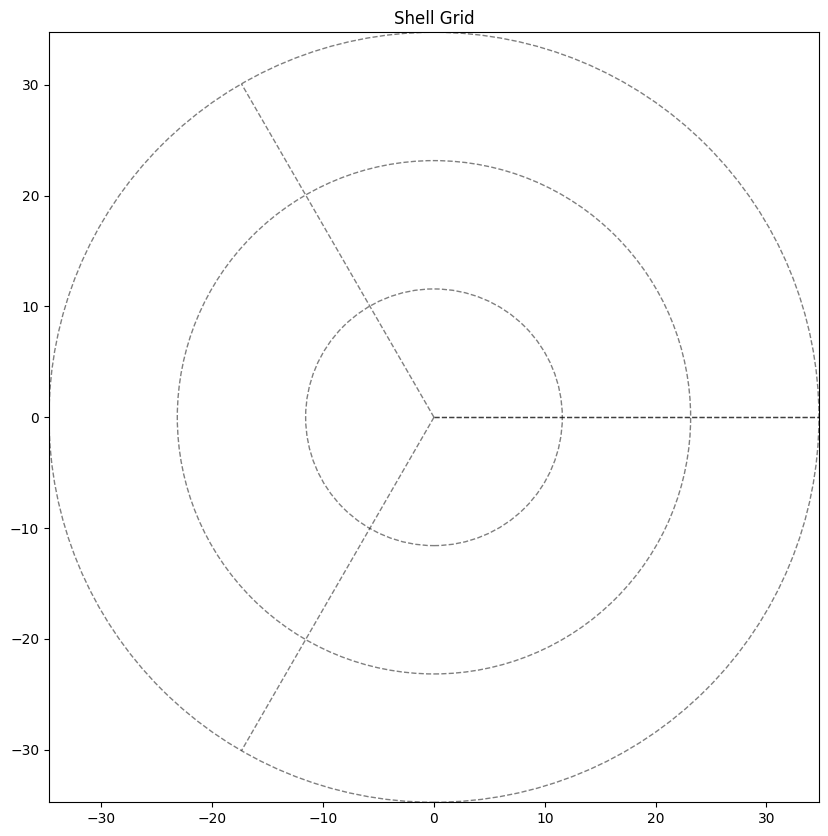

Rotation 1: Angle 0.0 degrees
  Shift 1:
Execution time (softmax): 0 minutes, 0 seconds and 59 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


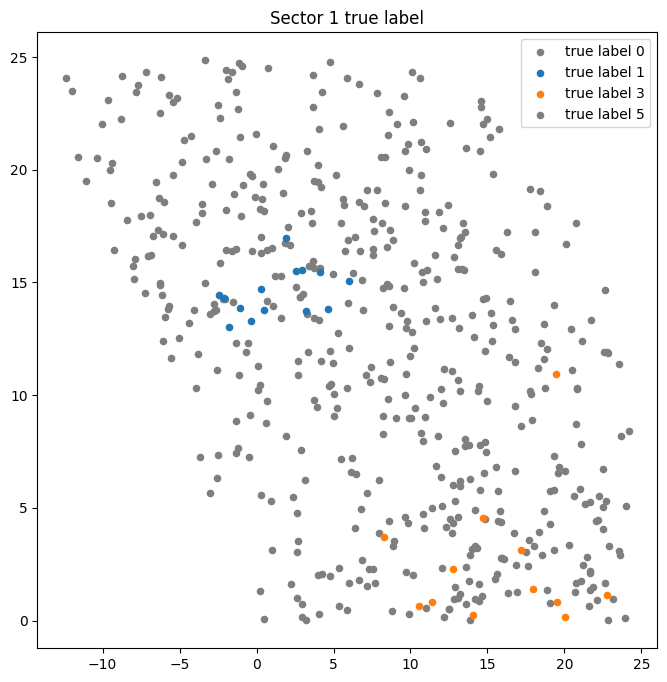

Execution time (softmax): 0 minutes, 4 seconds and 739 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


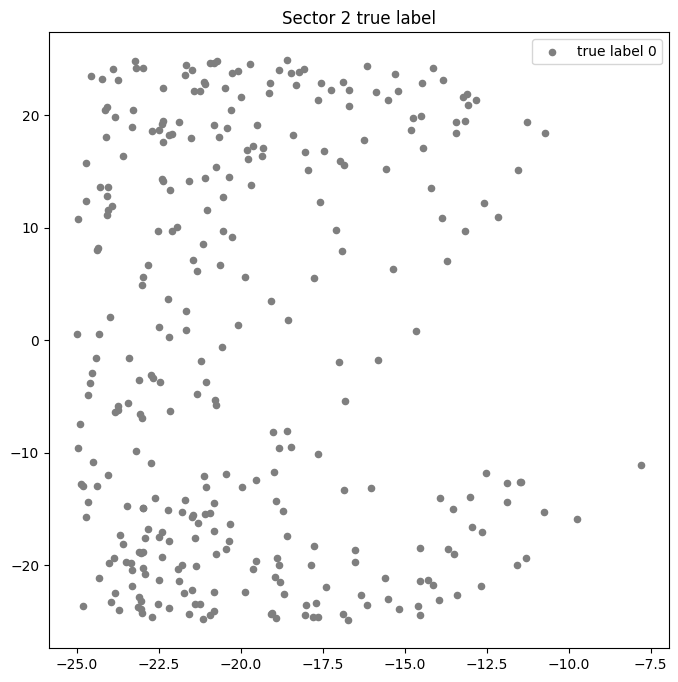

Execution time (softmax): 0 minutes, 0 seconds and 813 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


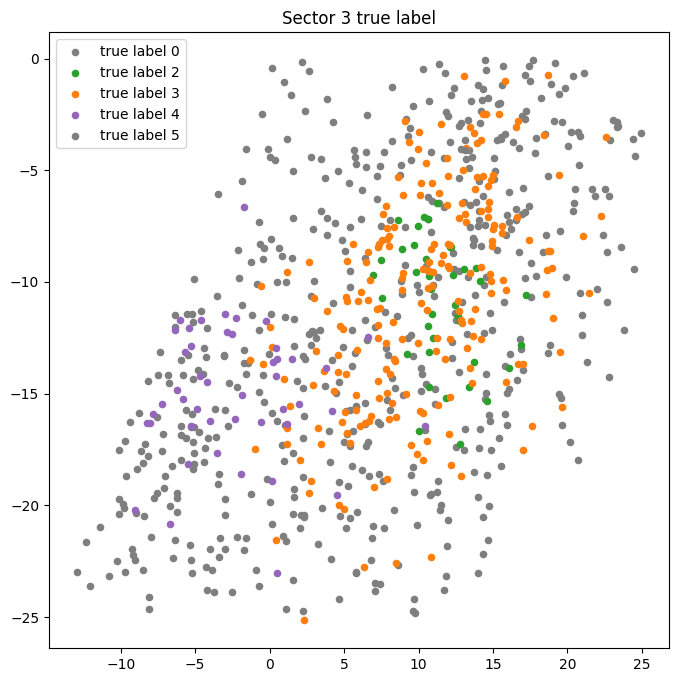

Execution time (softmax): 0 minutes, 0 seconds and 269 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


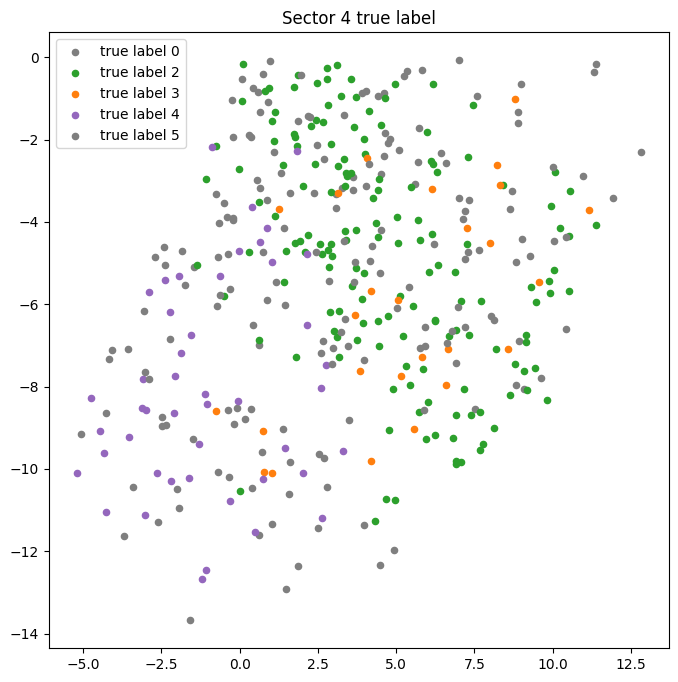

Execution time (softmax): 0 minutes, 0 seconds and 126 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


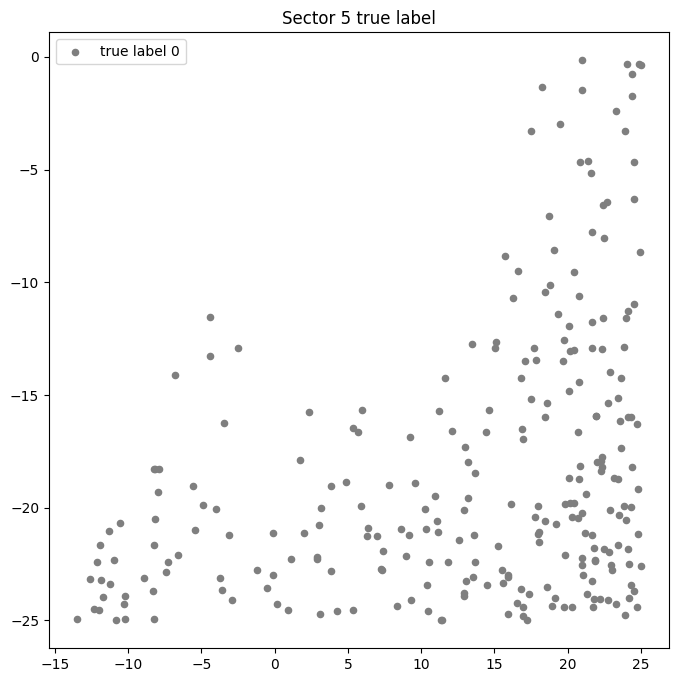

Execution time (softmax): 0 minutes, 0 seconds and 113 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


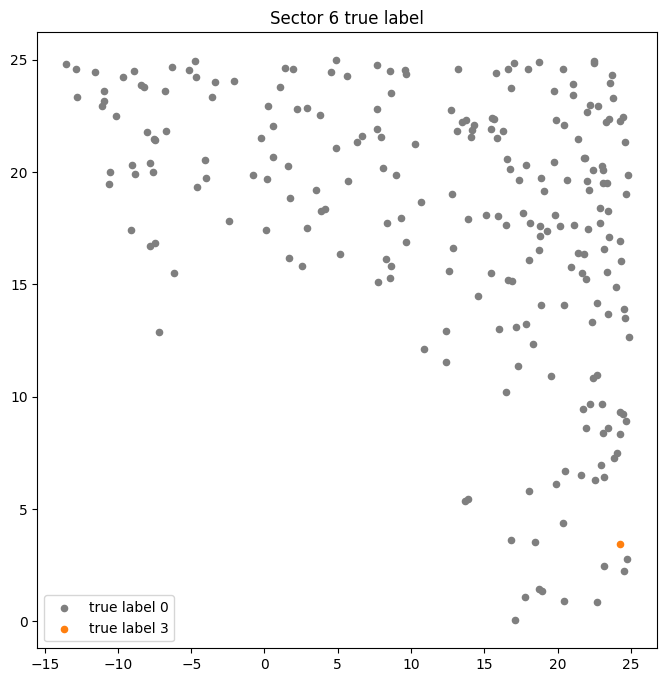

Execution time (softmax): 0 minutes, 0 seconds and 120 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


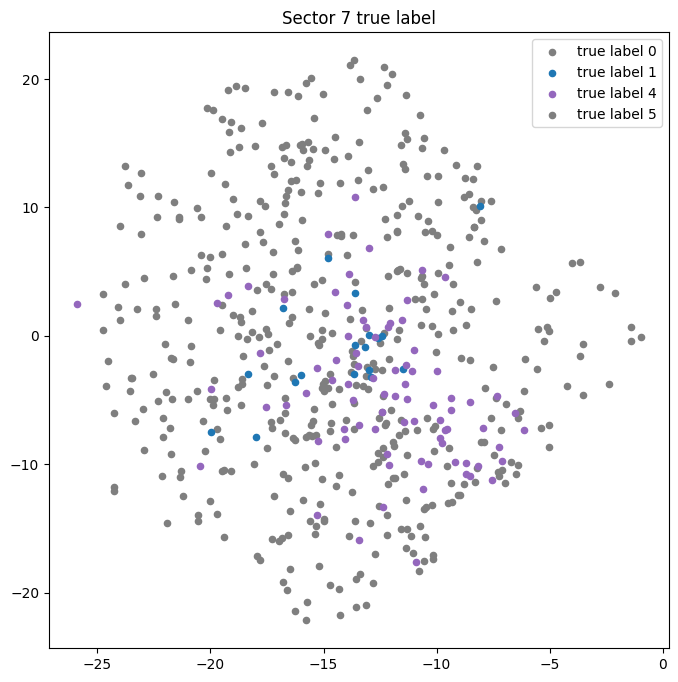

Execution time (softmax): 0 minutes, 0 seconds and 68 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


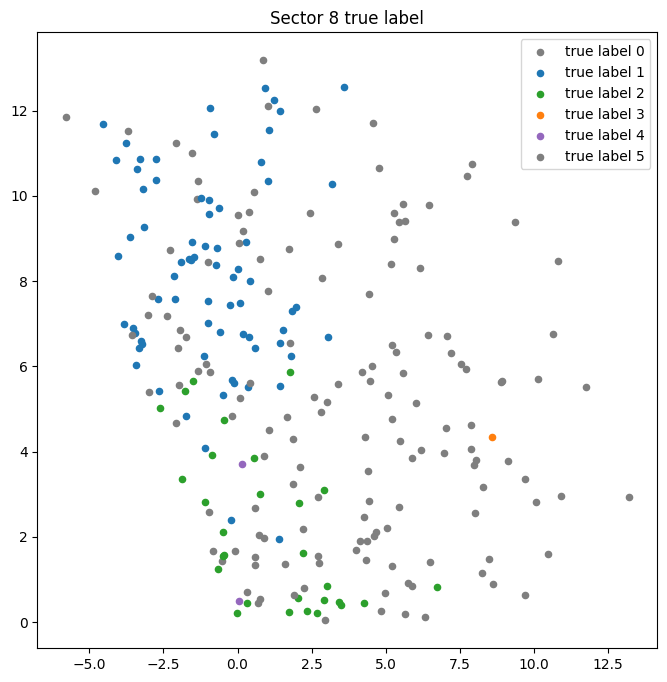

Execution time (softmax): 0 minutes, 0 seconds and 301 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


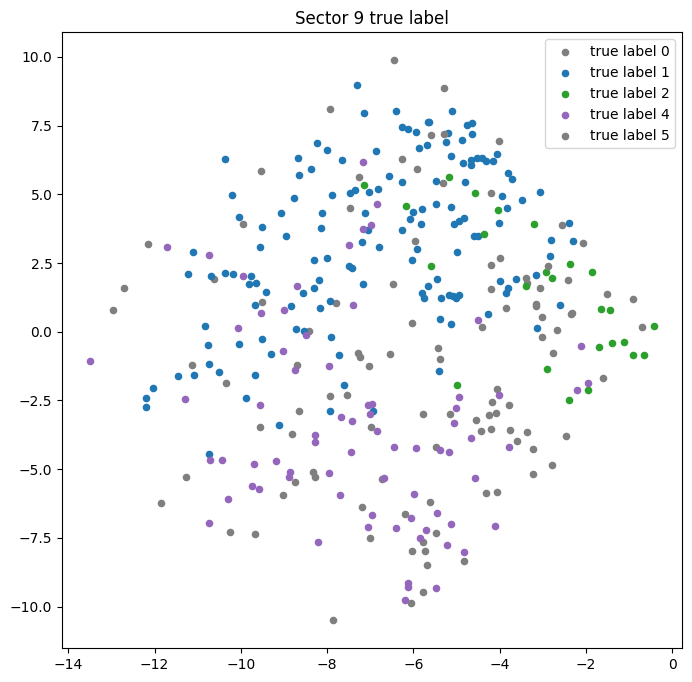

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


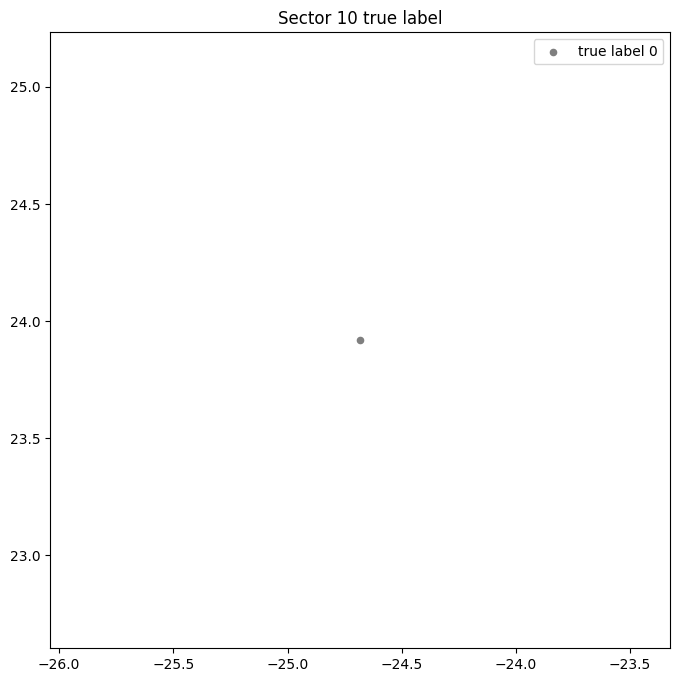

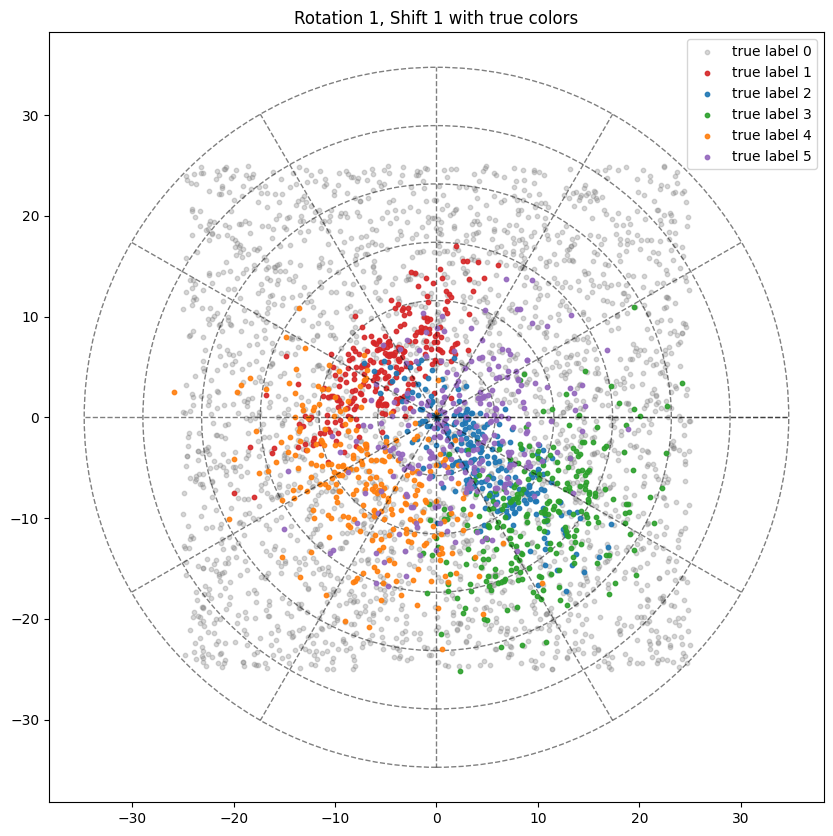

  Shift 2:
Execution time (softmax): 0 minutes, 0 seconds and 57 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


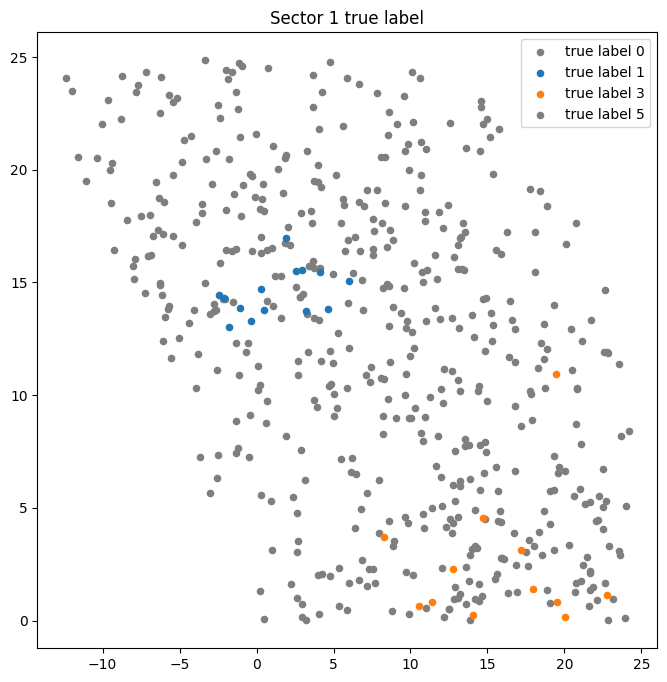

Execution time (softmax): 0 minutes, 4 seconds and 942 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


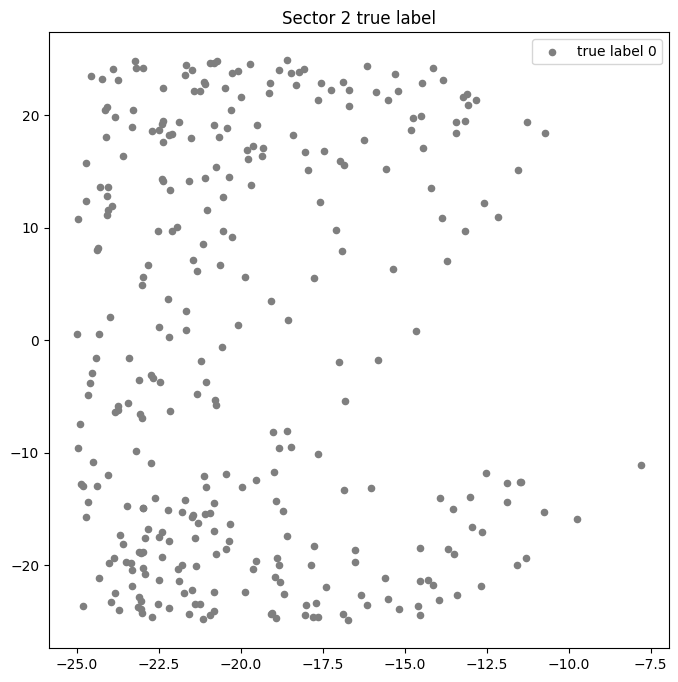

Execution time (softmax): 0 minutes, 0 seconds and 94 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


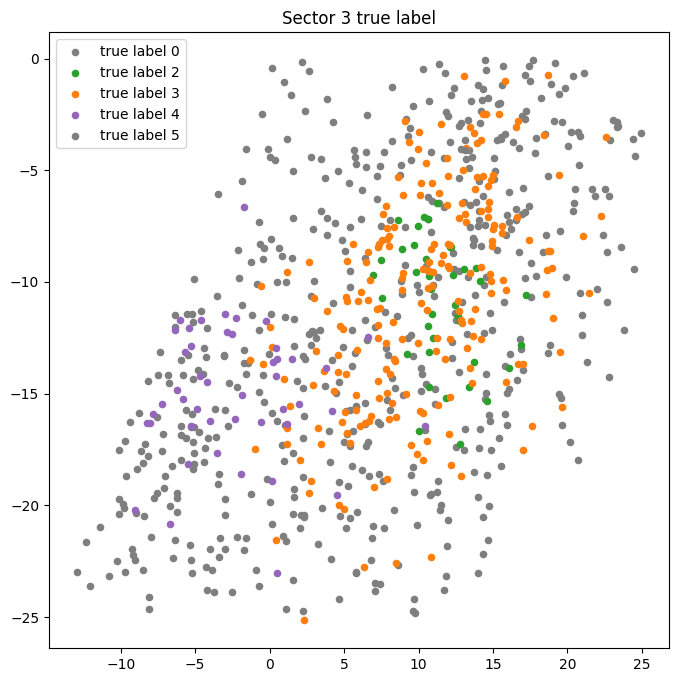

Execution time (softmax): 0 minutes, 0 seconds and 255 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


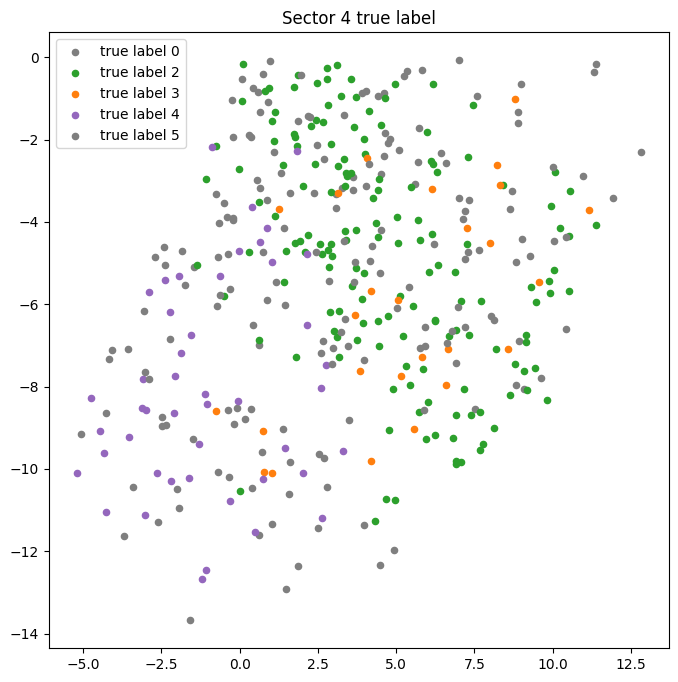

Execution time (softmax): 0 minutes, 0 seconds and 49 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


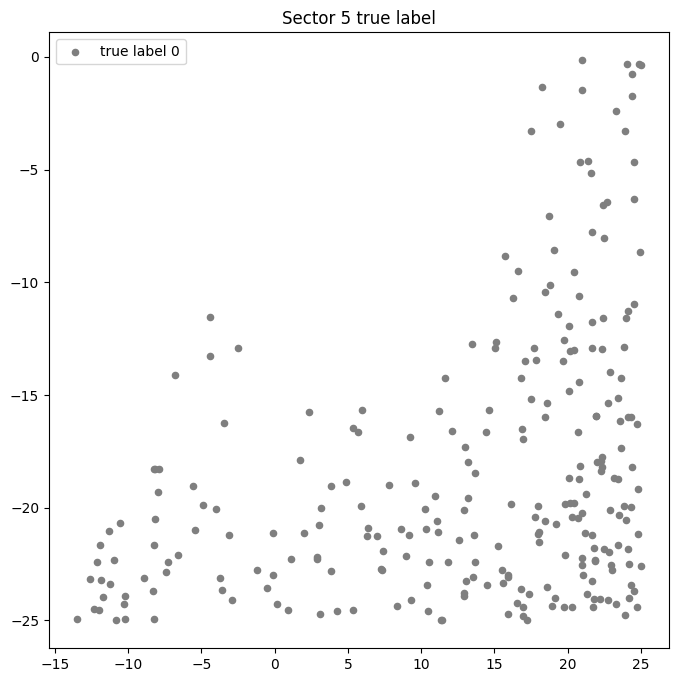

Execution time (softmax): 0 minutes, 0 seconds and 161 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


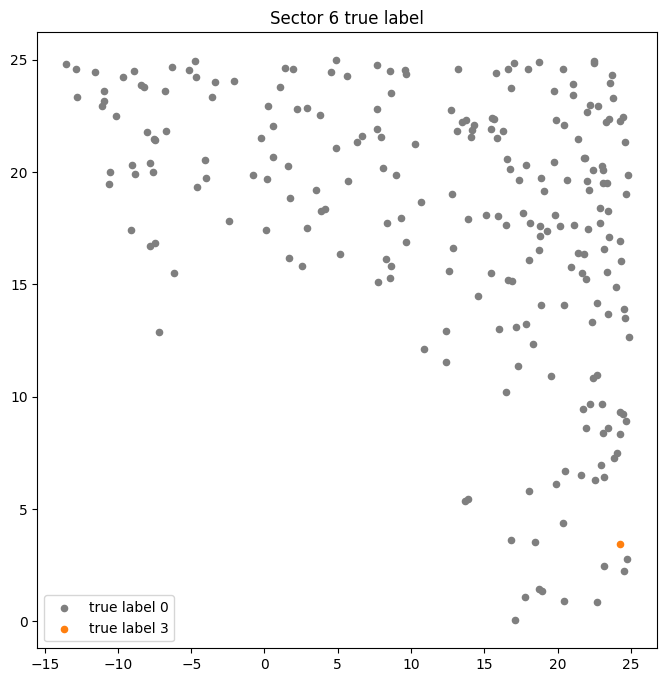

Execution time (softmax): 0 minutes, 0 seconds and 328 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


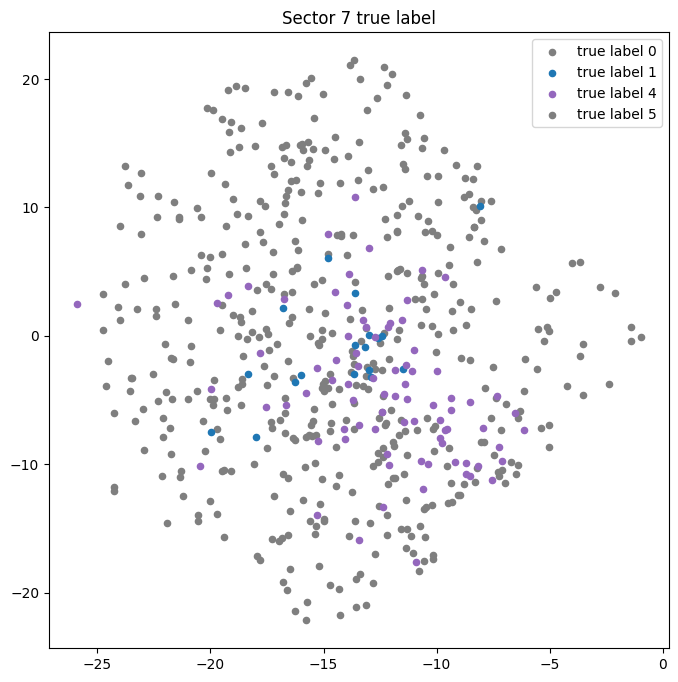

Execution time (softmax): 0 minutes, 0 seconds and 78 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


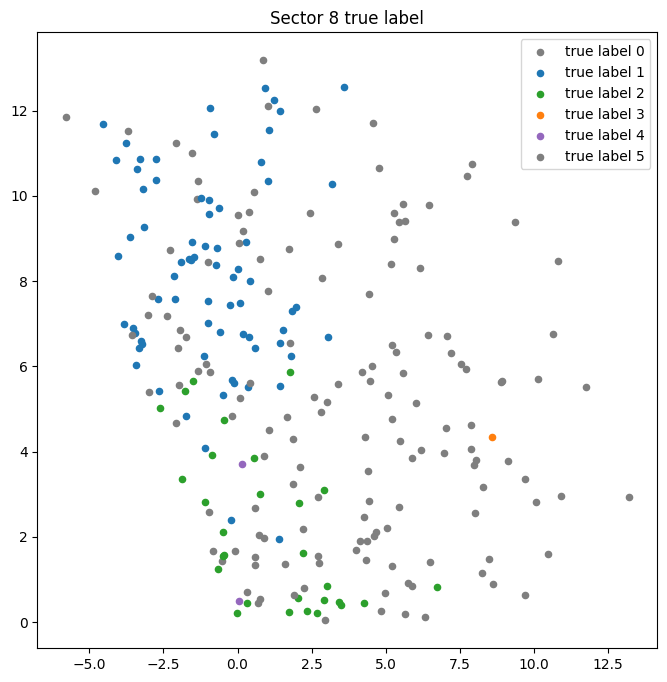

Execution time (softmax): 0 minutes, 0 seconds and 147 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


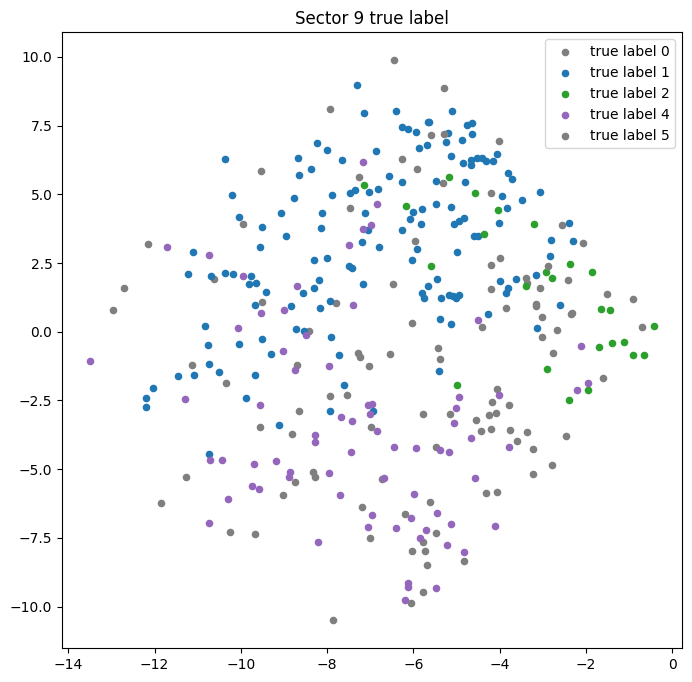

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


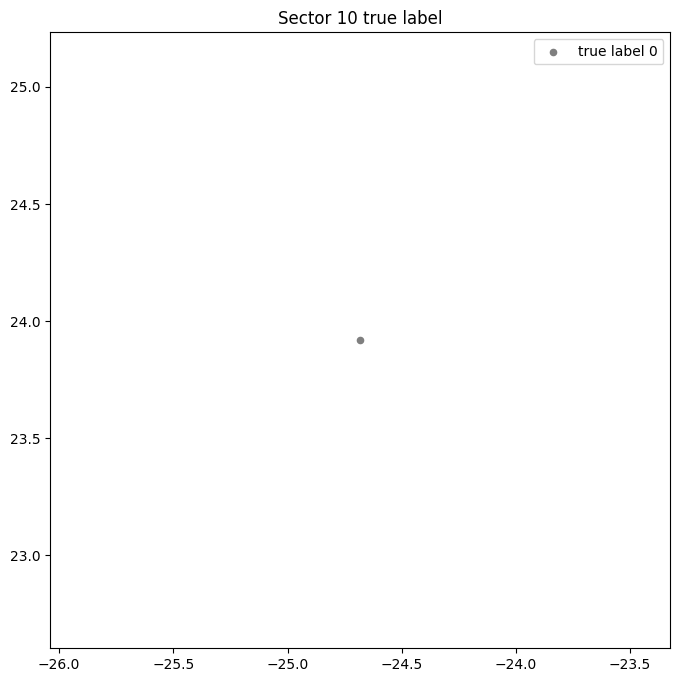

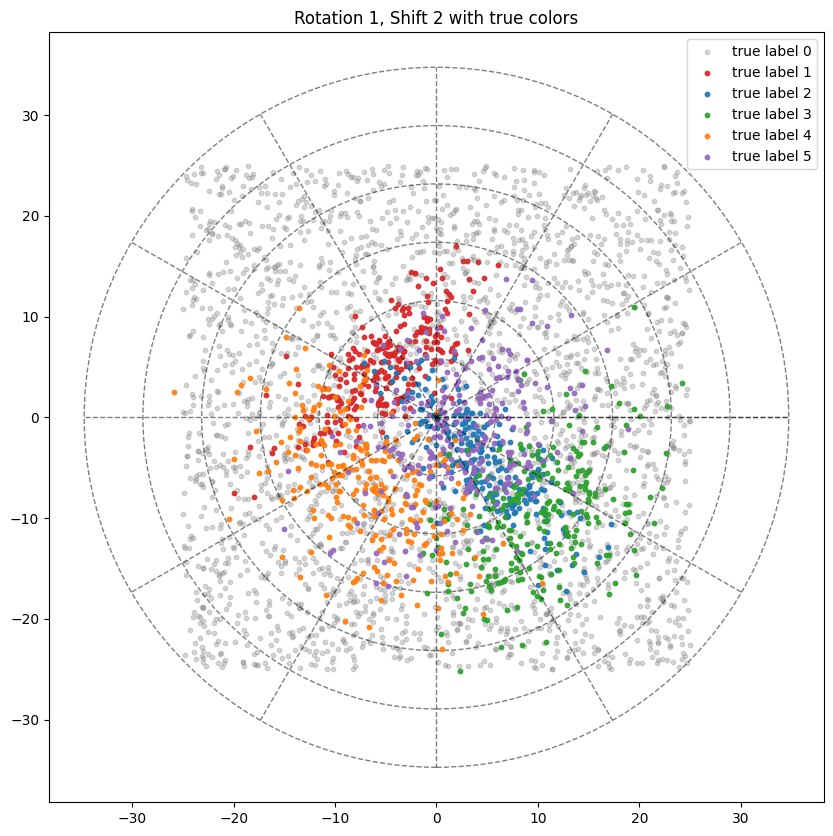

  Shift 3:
Execution time (softmax): 0 minutes, 0 seconds and 39 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


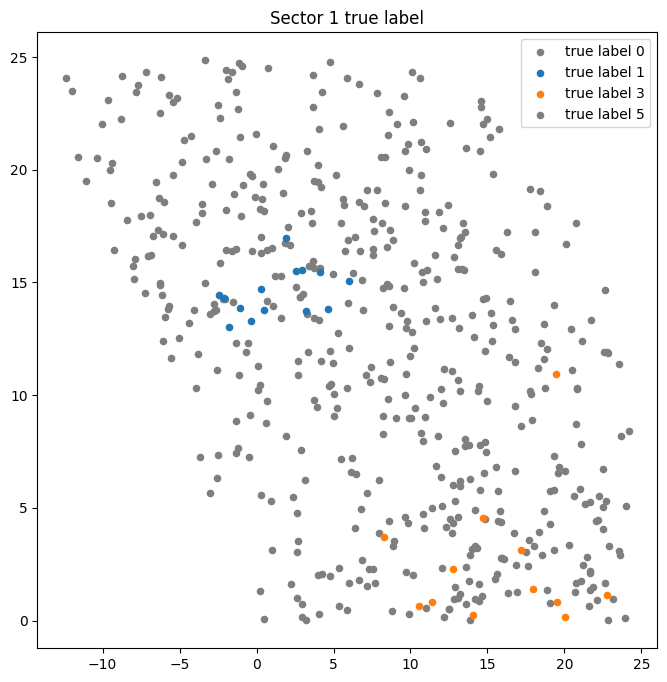

Execution time (softmax): 0 minutes, 0 seconds and 190 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


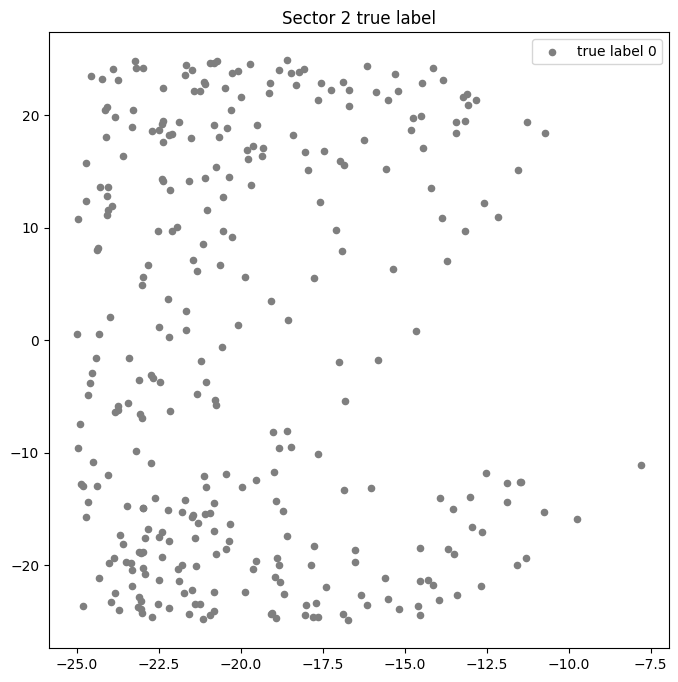

Execution time (softmax): 0 minutes, 0 seconds and 81 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


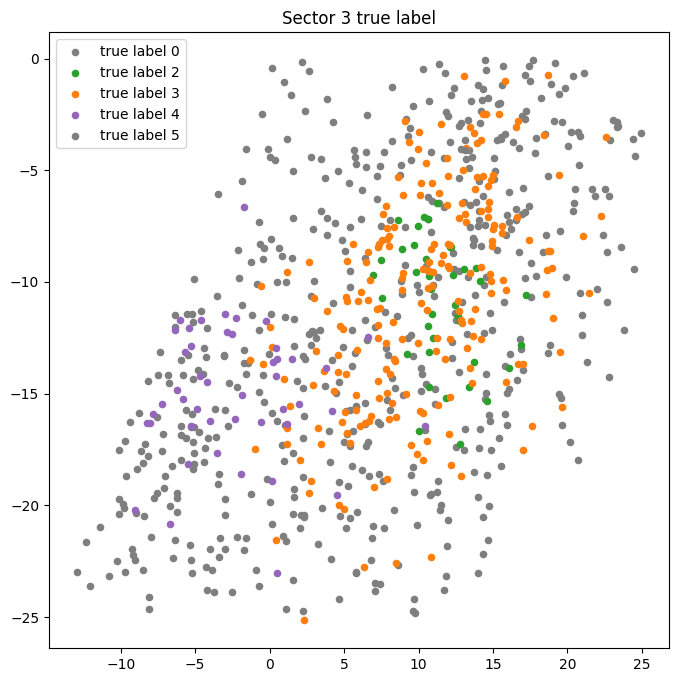

Execution time (softmax): 0 minutes, 0 seconds and 156 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


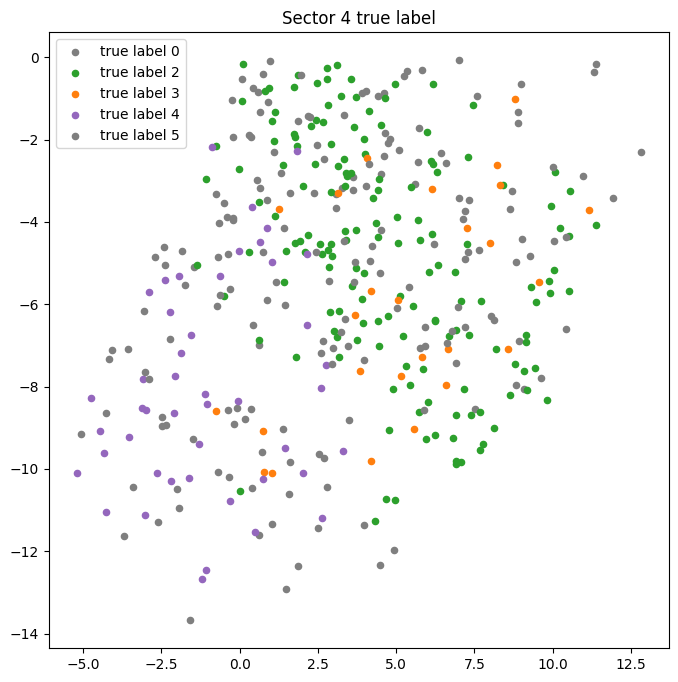

Execution time (softmax): 0 minutes, 0 seconds and 74 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


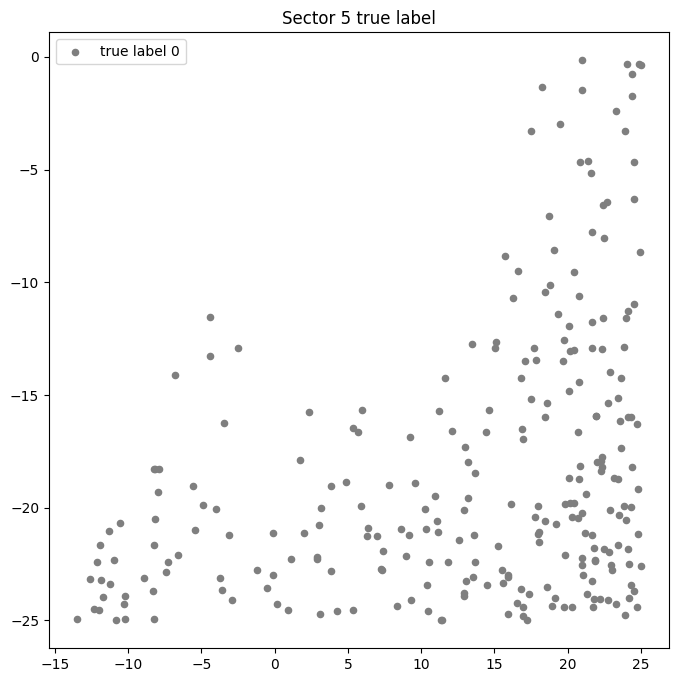

Execution time (softmax): 0 minutes, 0 seconds and 228 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


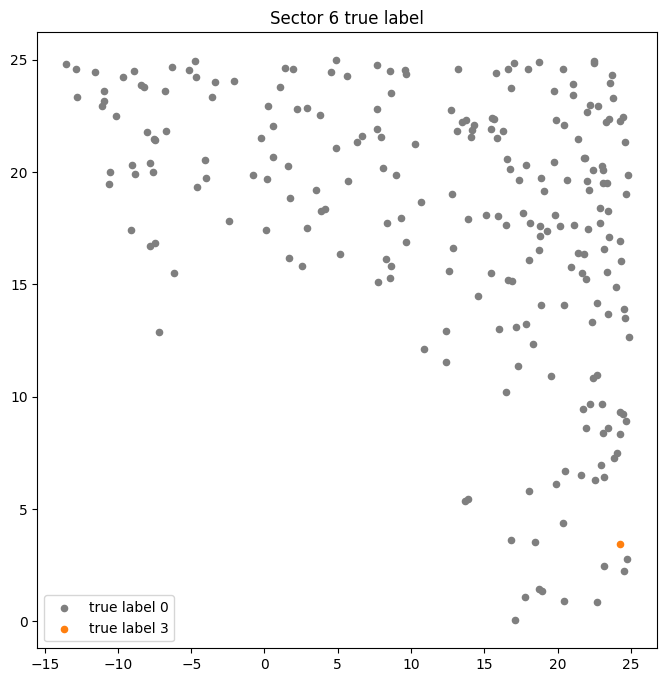

Execution time (softmax): 0 minutes, 0 seconds and 121 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


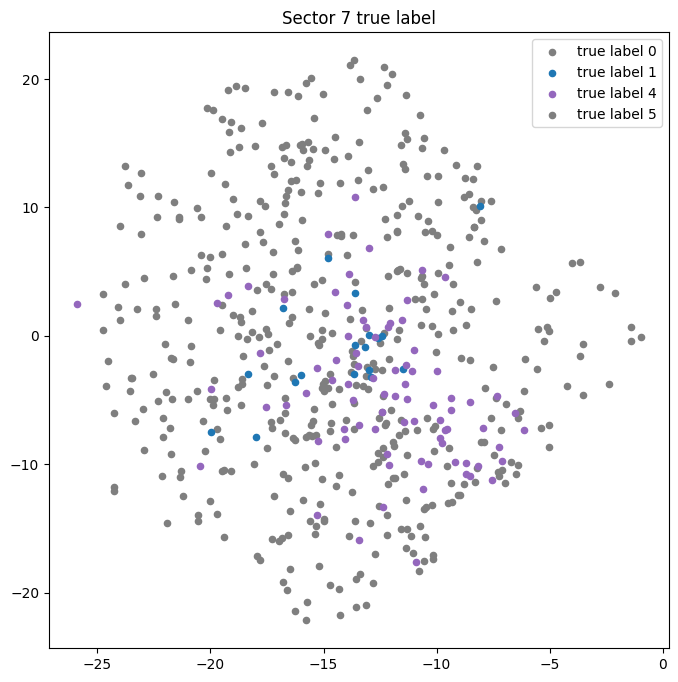

Execution time (softmax): 0 minutes, 0 seconds and 149 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


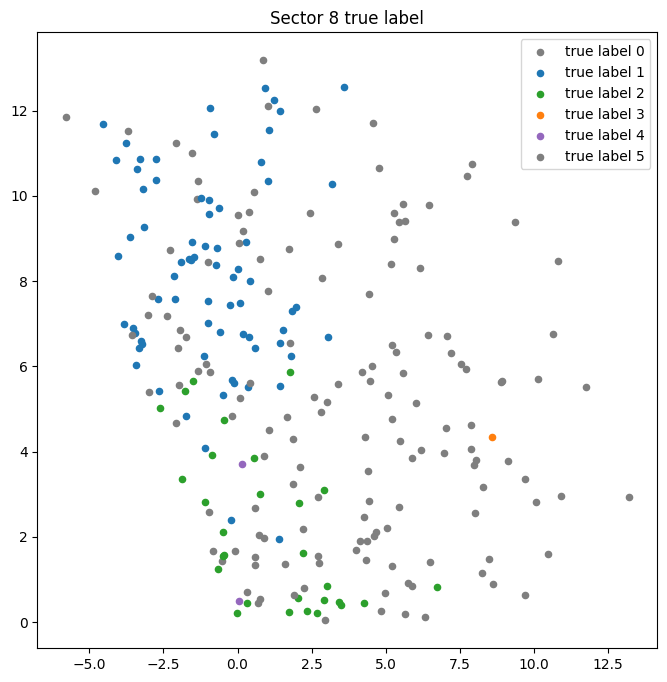

Execution time (softmax): 0 minutes, 0 seconds and 109 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


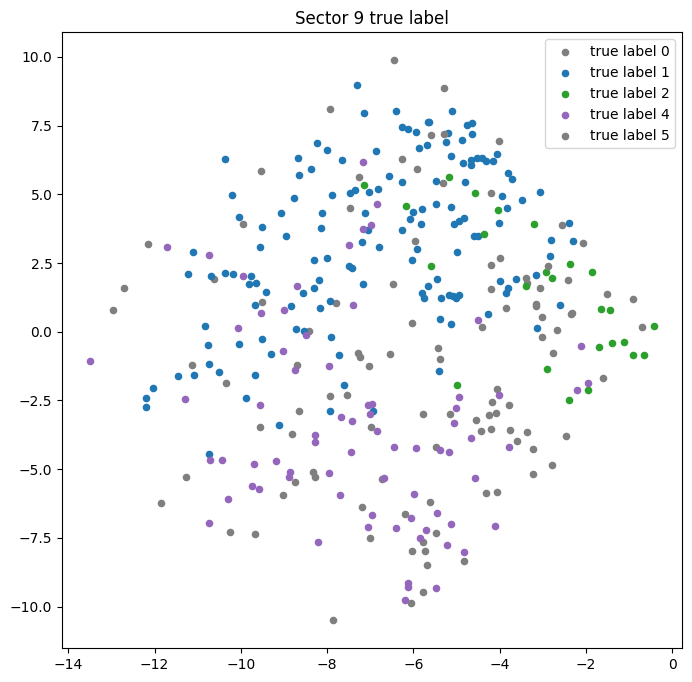

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


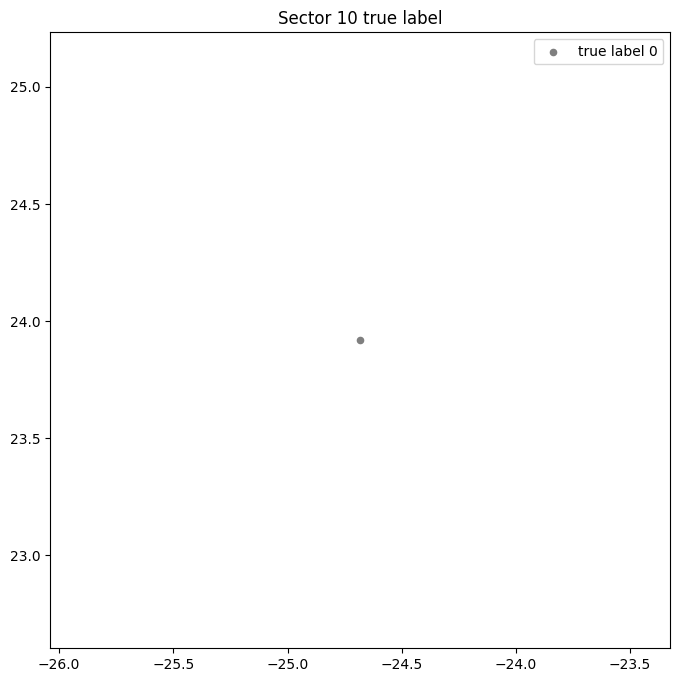

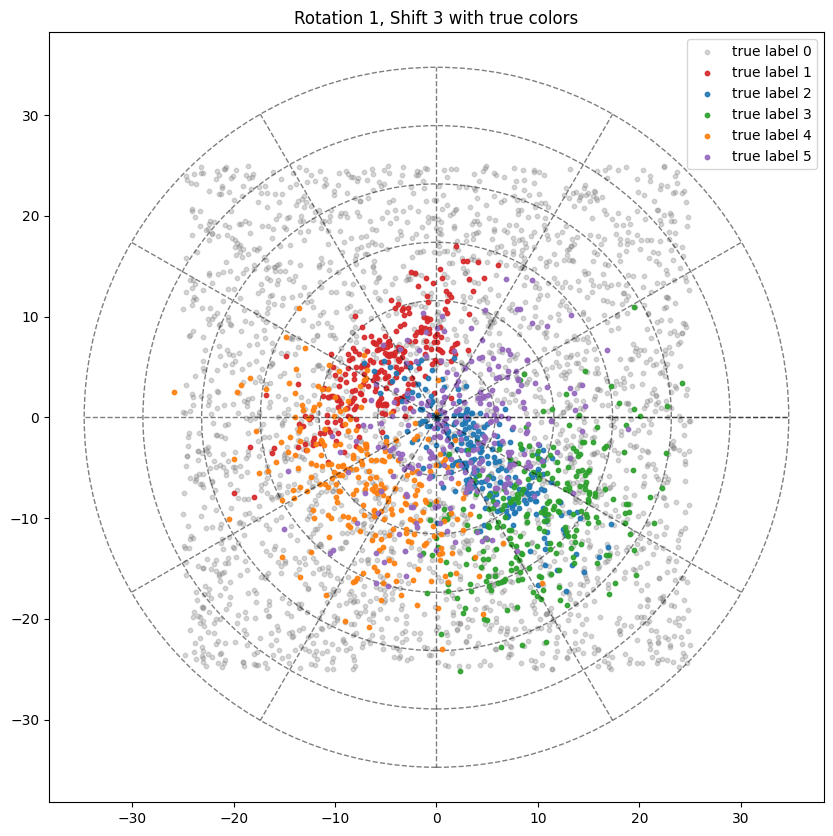

Rotation 2: Angle 120.0 degrees
  Shift 1:
Execution time (softmax): 0 minutes, 0 seconds and 207 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


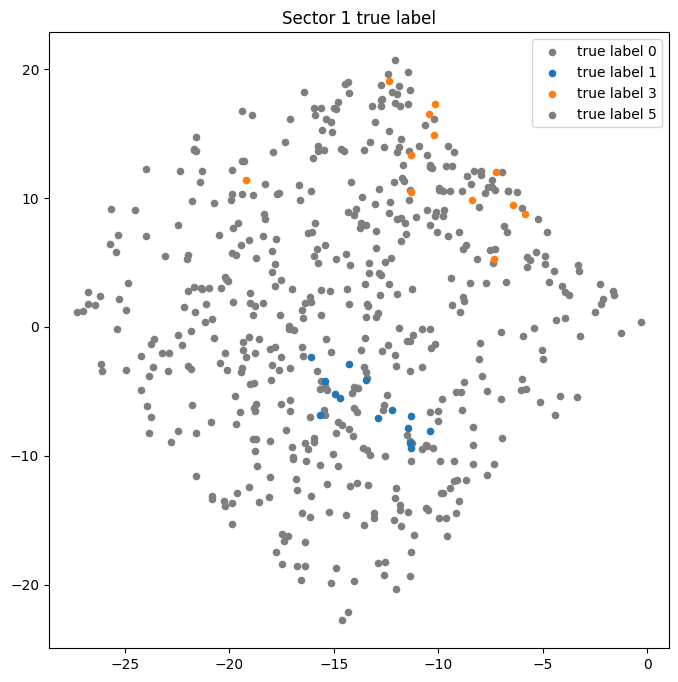

Execution time (softmax): 0 minutes, 0 seconds and 201 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


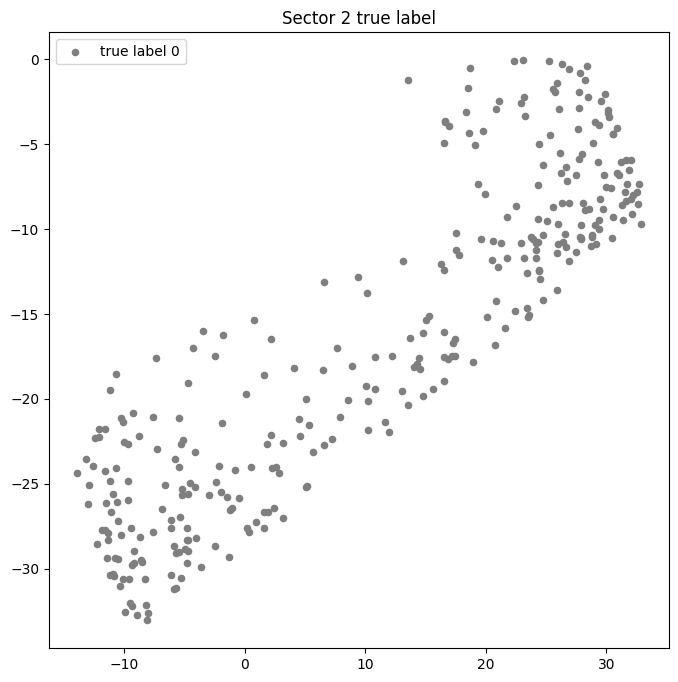

Execution time (softmax): 0 minutes, 0 seconds and 99 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


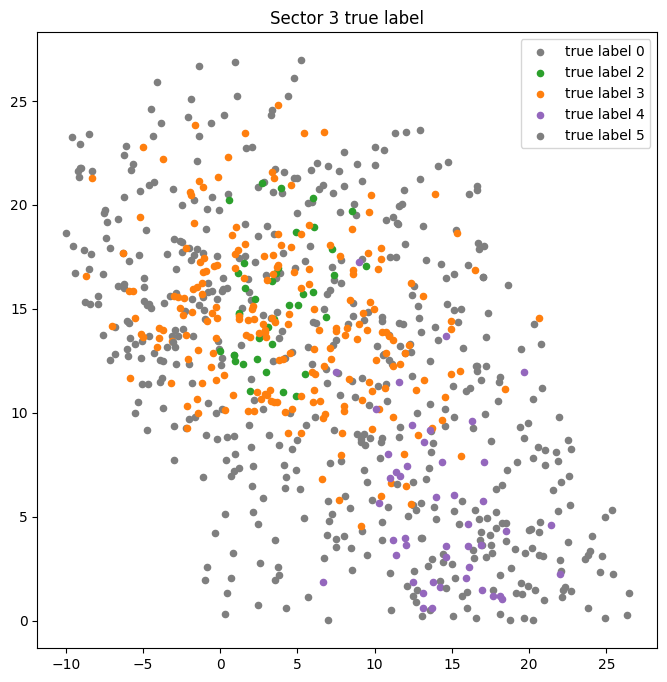

Execution time (softmax): 0 minutes, 0 seconds and 301 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


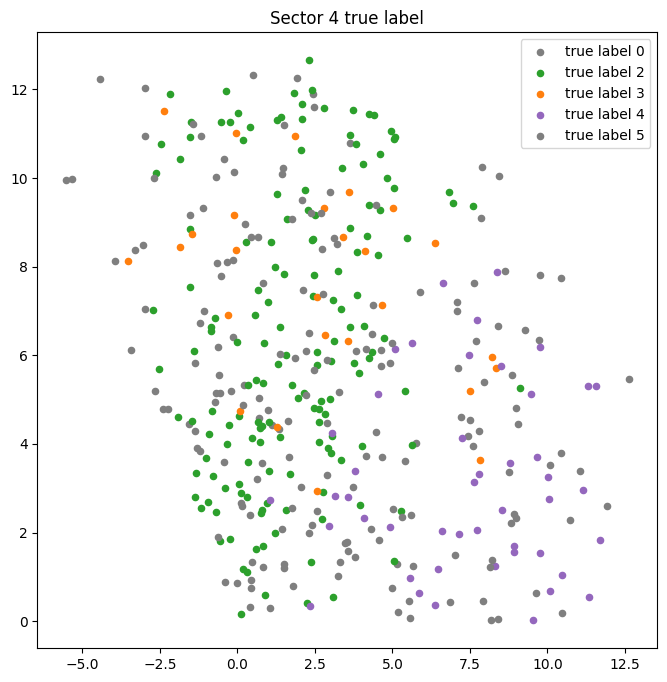

Execution time (softmax): 0 minutes, 0 seconds and 177 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


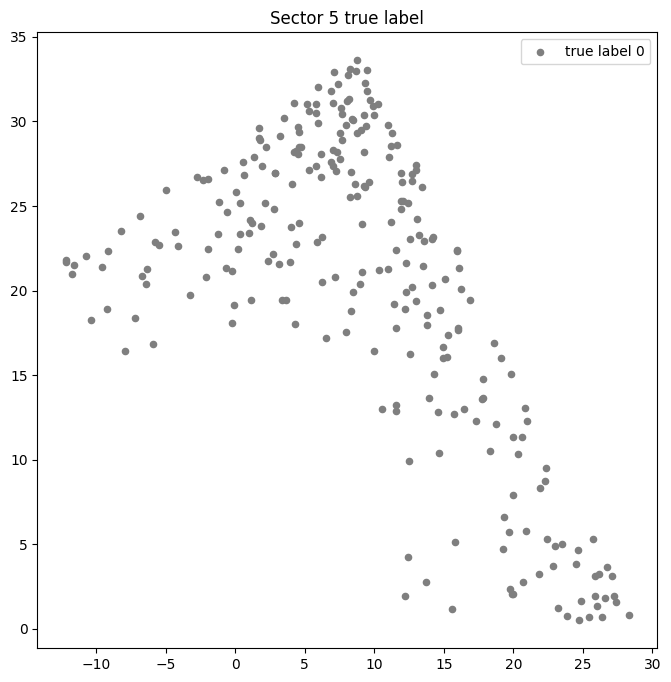

Execution time (softmax): 0 minutes, 0 seconds and 150 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


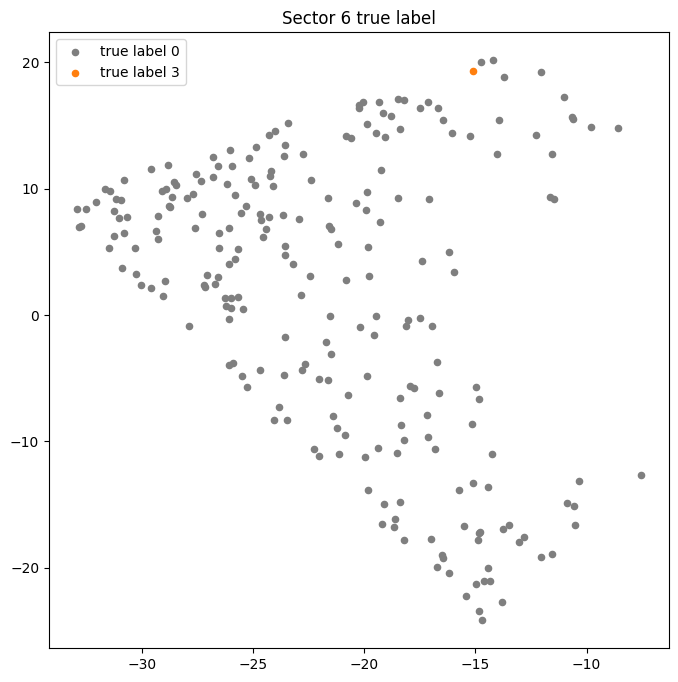

Execution time (softmax): 0 minutes, 0 seconds and 209 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


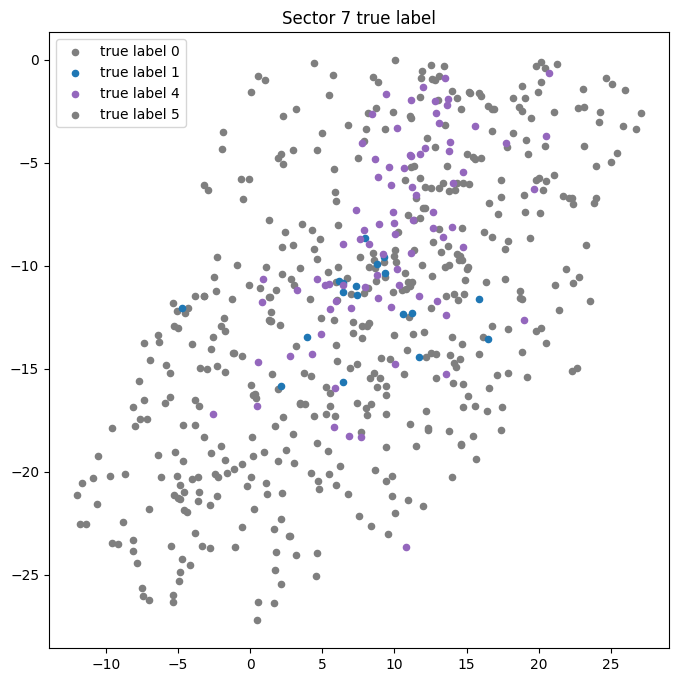

Execution time (softmax): 0 minutes, 0 seconds and 40 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


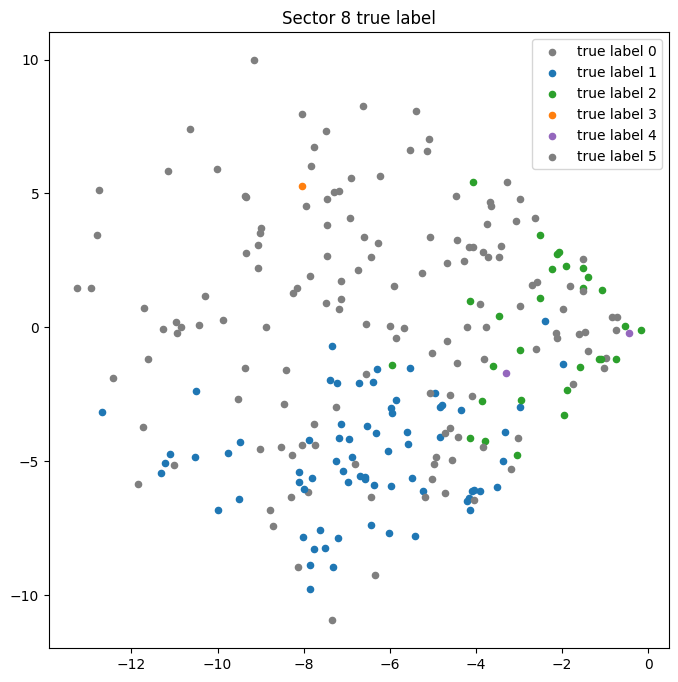

Execution time (softmax): 0 minutes, 0 seconds and 259 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


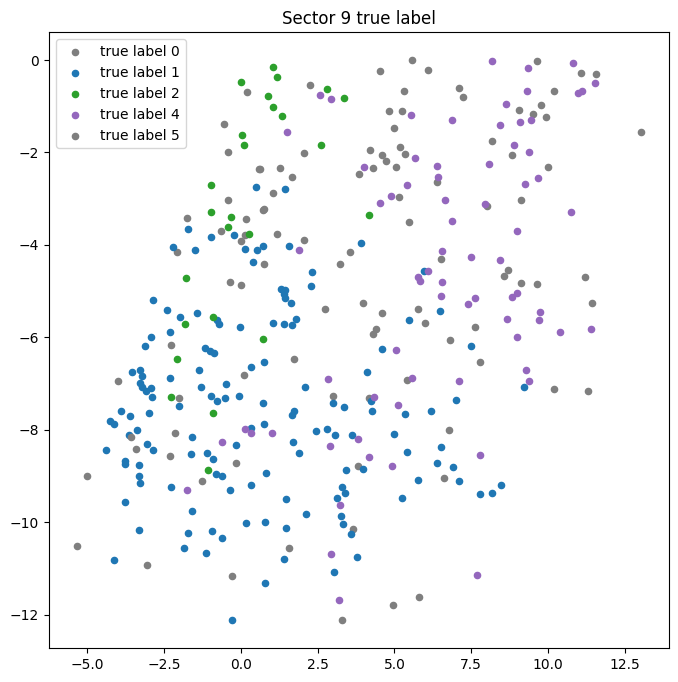

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


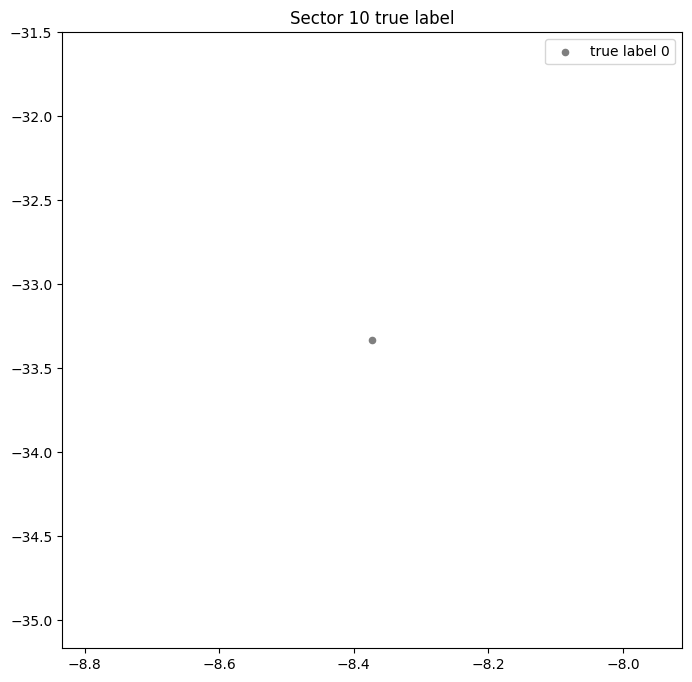

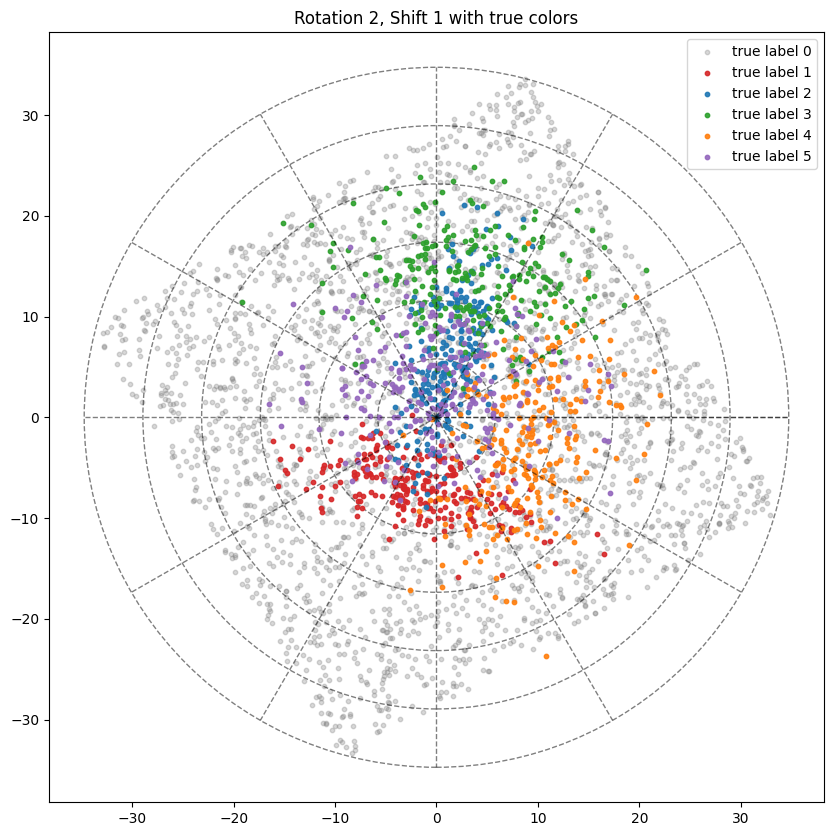

  Shift 2:
Execution time (softmax): 0 minutes, 0 seconds and 134 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


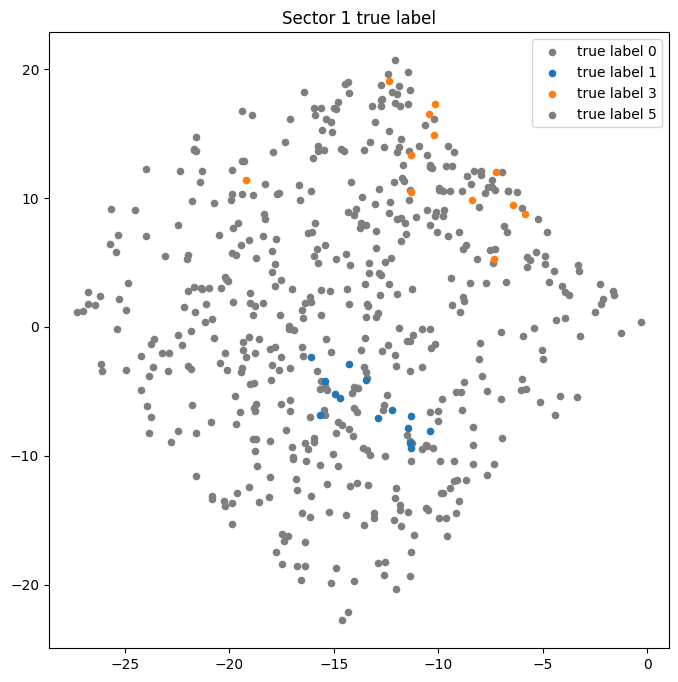

Execution time (softmax): 0 minutes, 0 seconds and 408 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


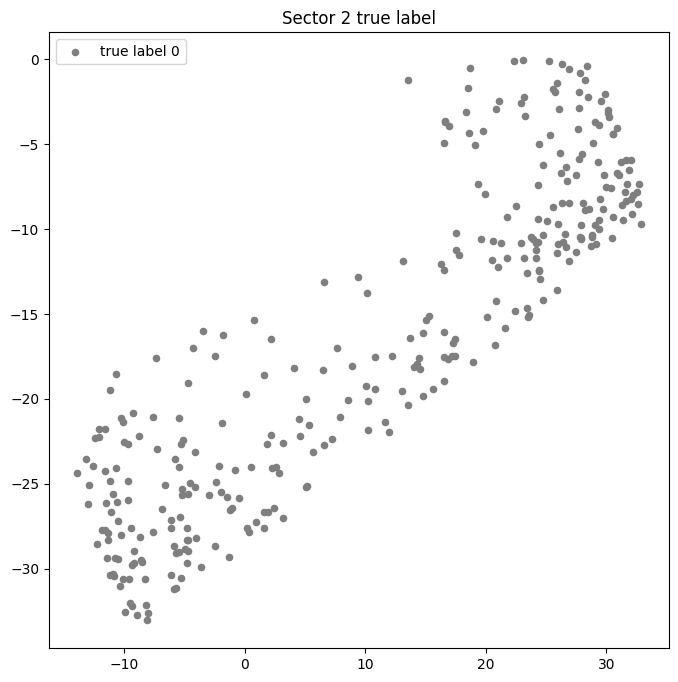

Execution time (softmax): 0 minutes, 0 seconds and 78 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


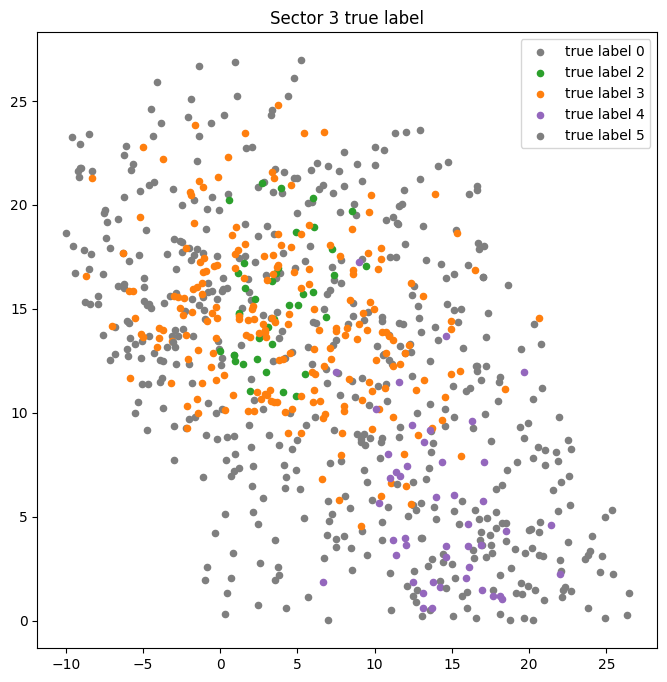

Execution time (softmax): 0 minutes, 0 seconds and 307 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


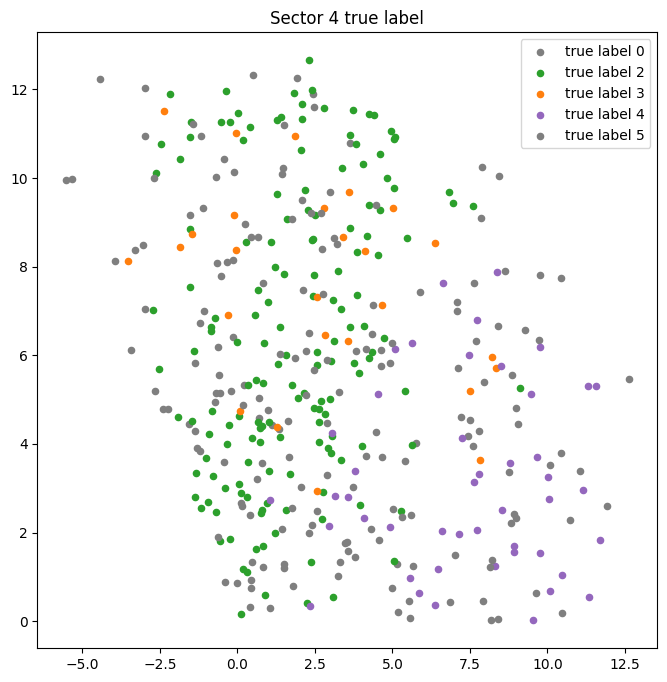

Execution time (softmax): 0 minutes, 0 seconds and 45 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


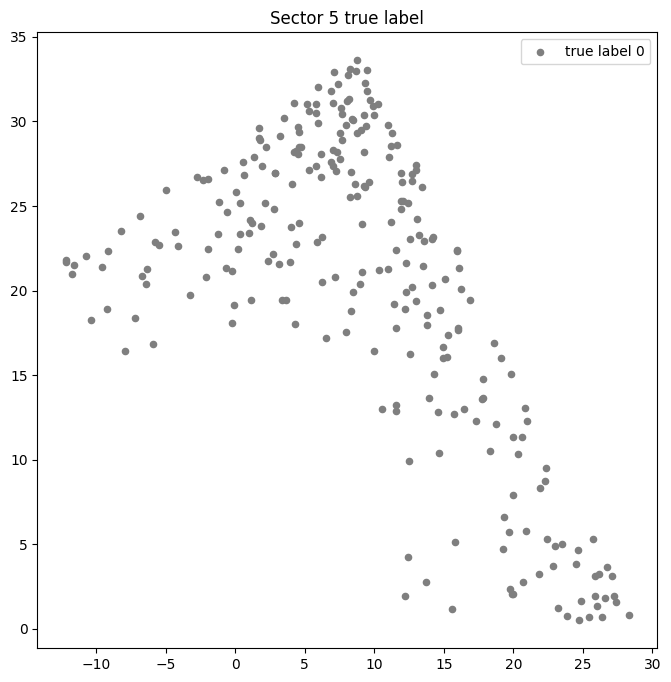

Execution time (softmax): 0 minutes, 0 seconds and 91 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


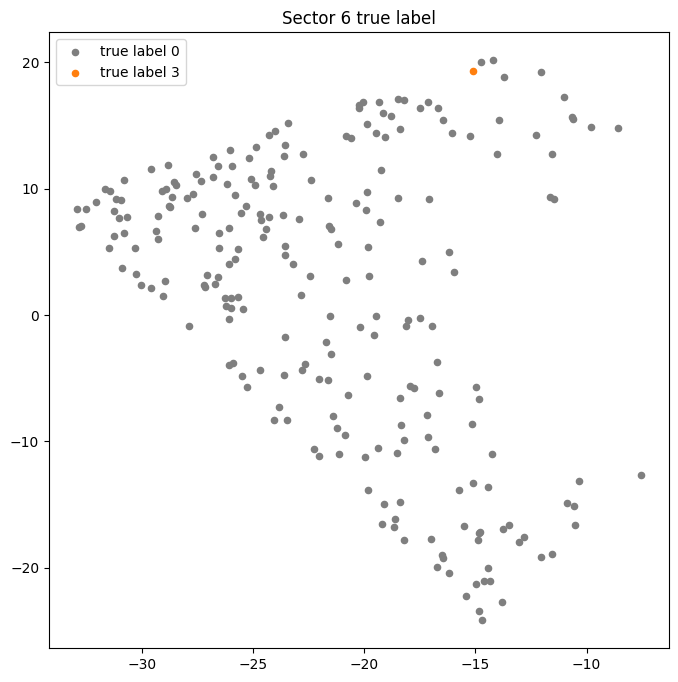

Execution time (softmax): 0 minutes, 0 seconds and 396 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


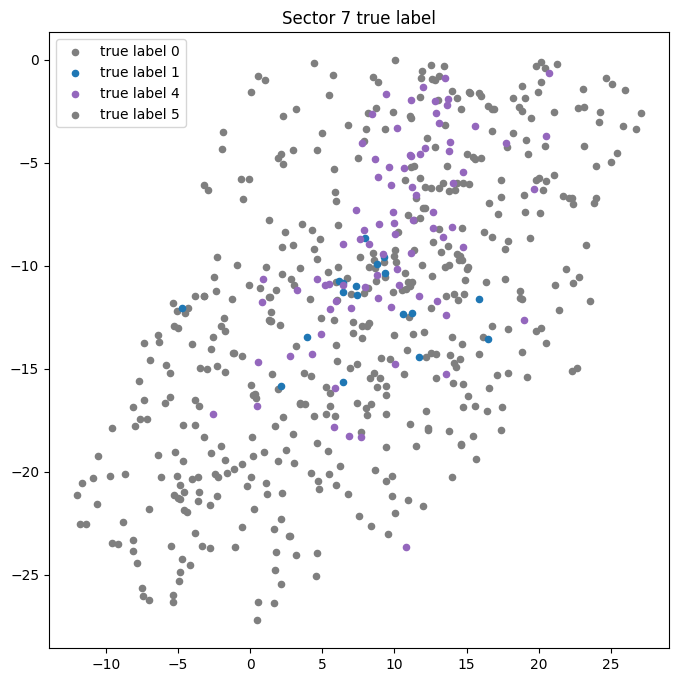

Execution time (softmax): 0 minutes, 0 seconds and 143 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


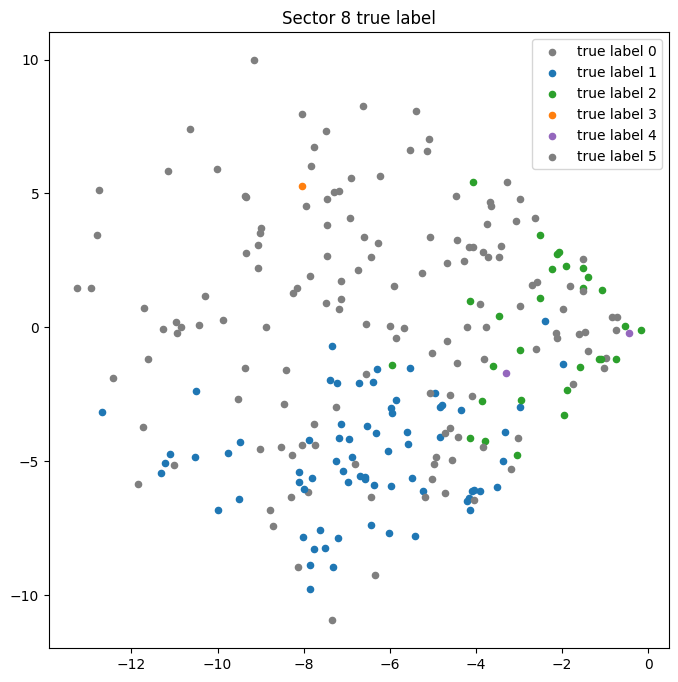

Execution time (softmax): 0 minutes, 0 seconds and 242 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


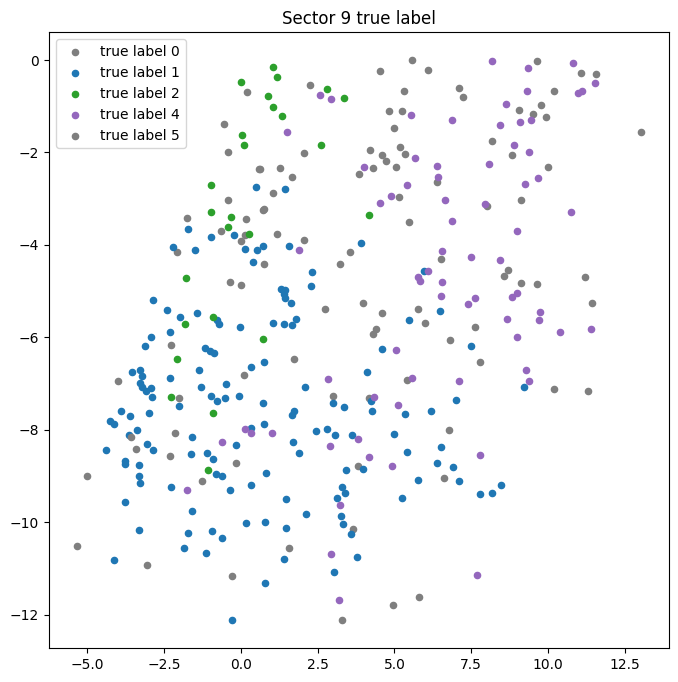

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


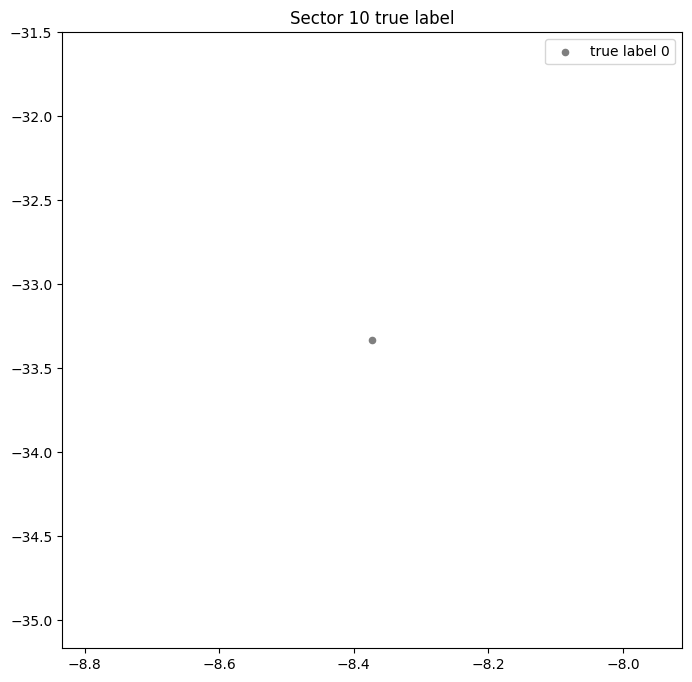

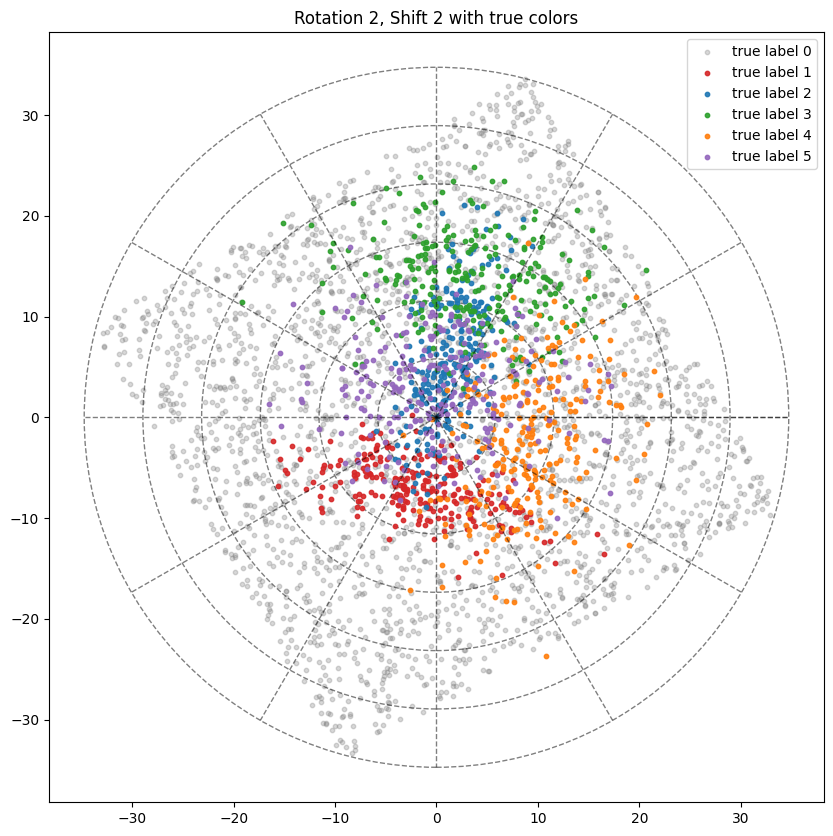

  Shift 3:
Execution time (softmax): 0 minutes, 0 seconds and 55 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


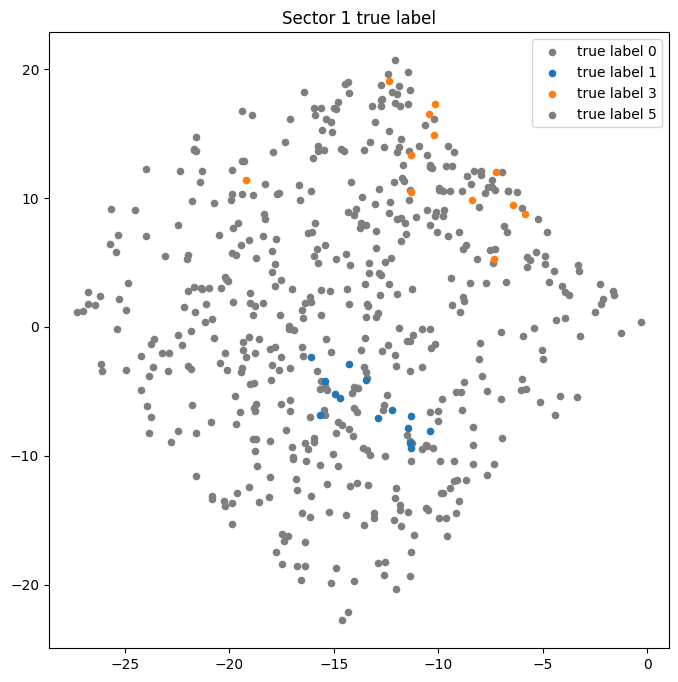

Execution time (softmax): 0 minutes, 0 seconds and 601 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


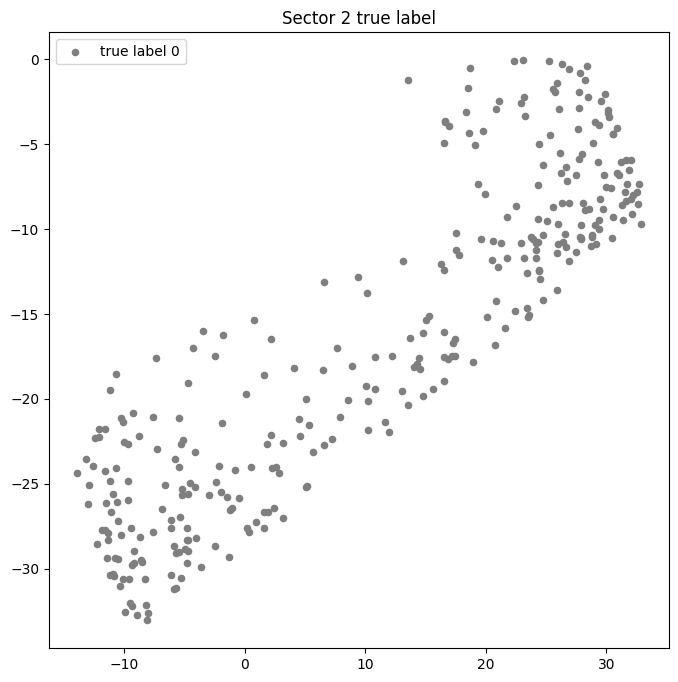

Execution time (softmax): 0 minutes, 0 seconds and 256 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


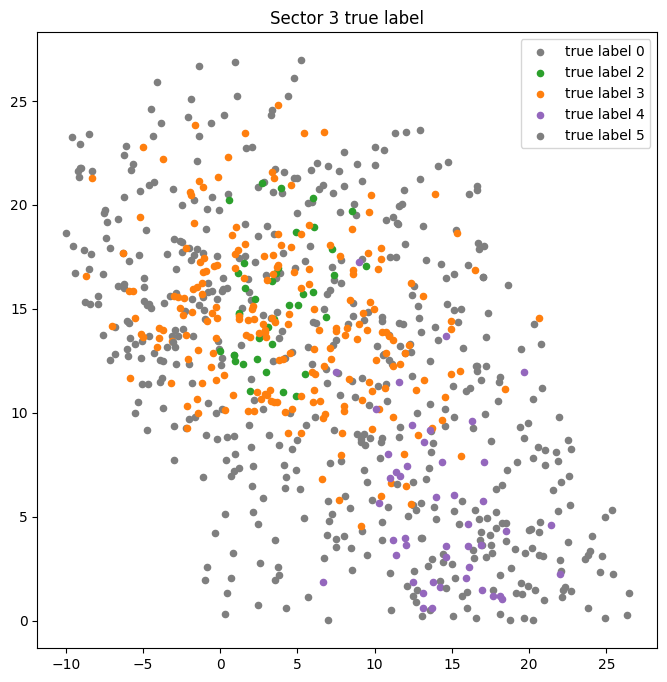

Execution time (softmax): 0 minutes, 4 seconds and 159 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


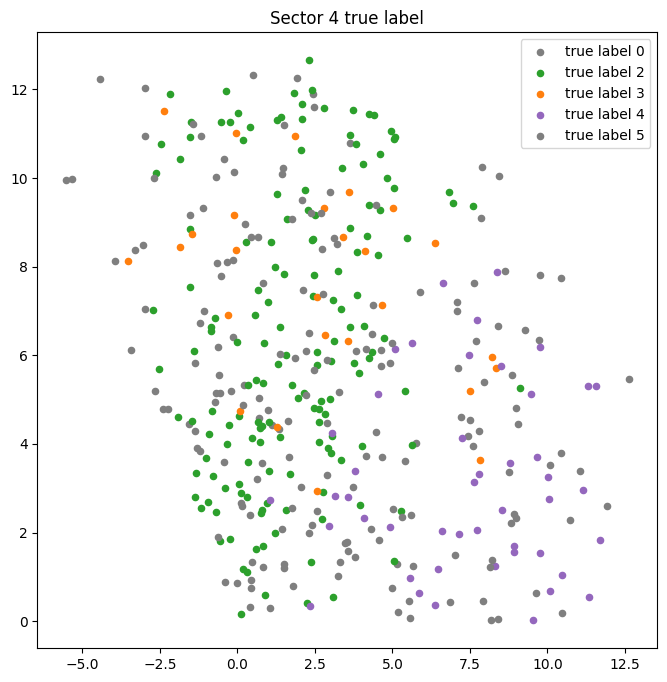

Execution time (softmax): 0 minutes, 3 seconds and 369 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


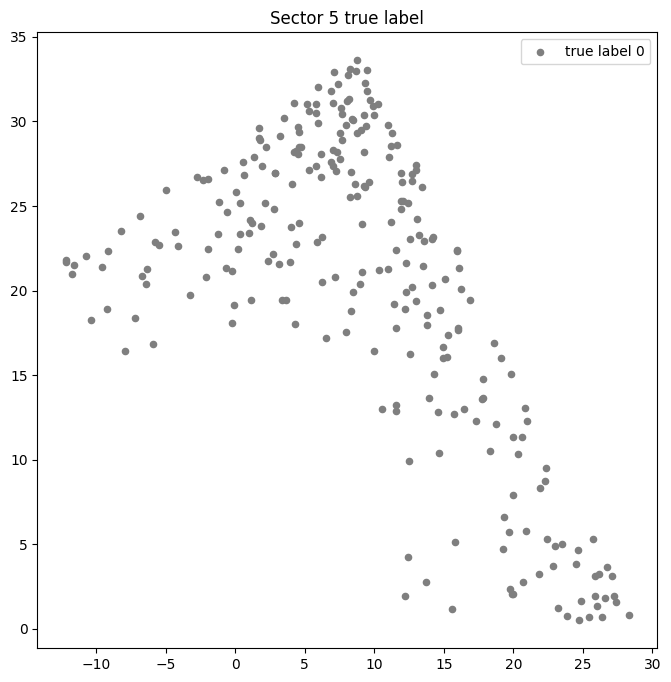

Execution time (softmax): 0 minutes, 5 seconds and 149 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


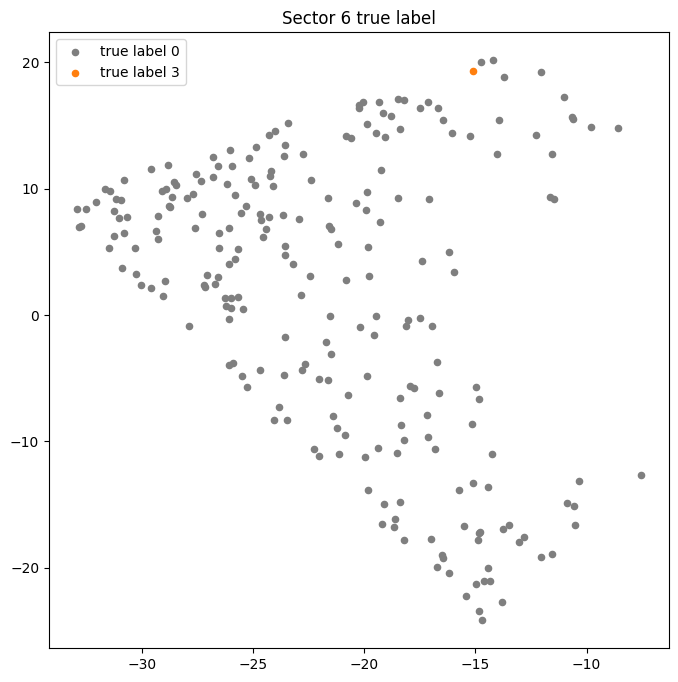

Execution time (softmax): 0 minutes, 3 seconds and 539 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


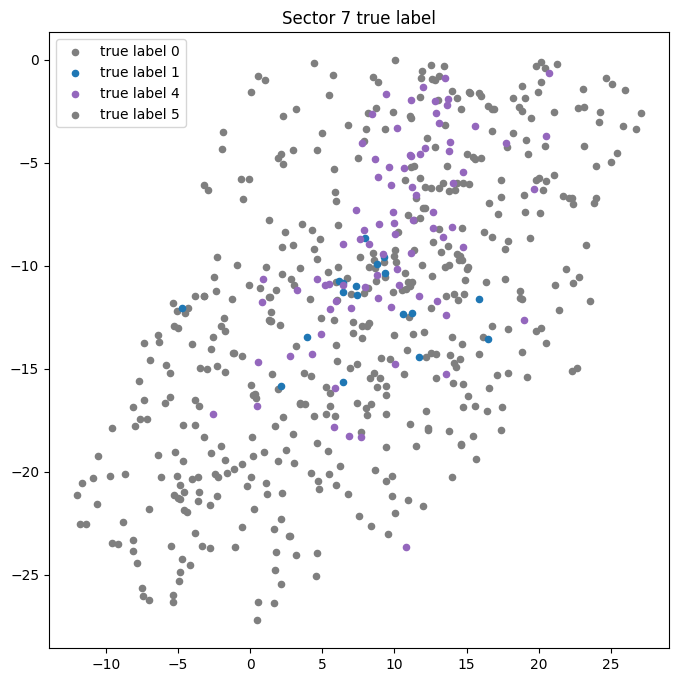

Execution time (softmax): 0 minutes, 2 seconds and 272 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


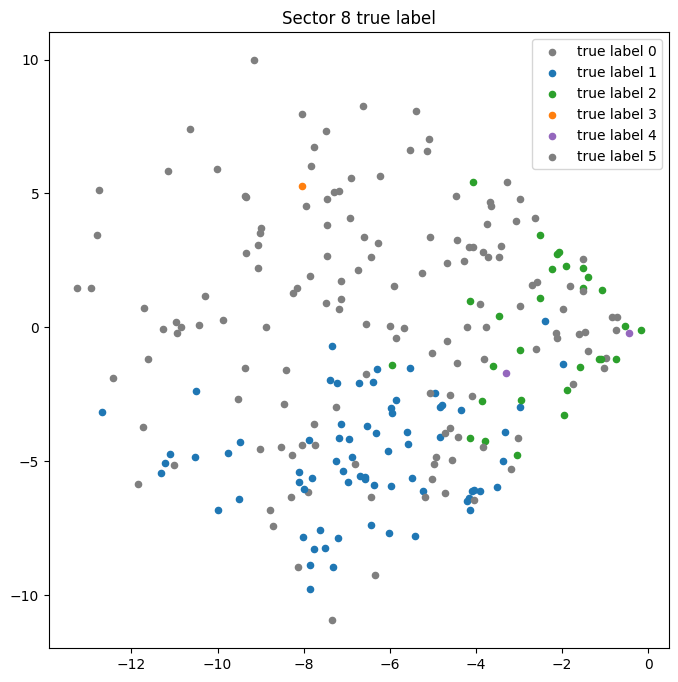

Execution time (softmax): 0 minutes, 4 seconds and 721 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


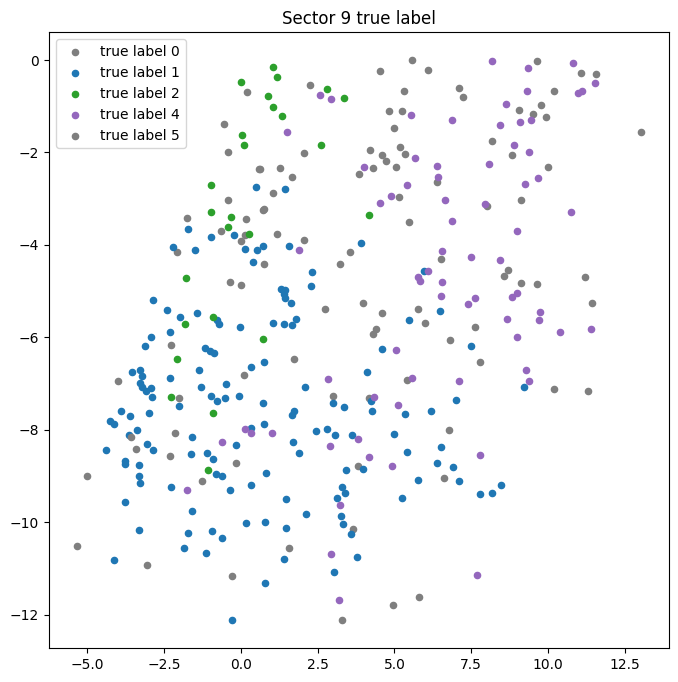

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


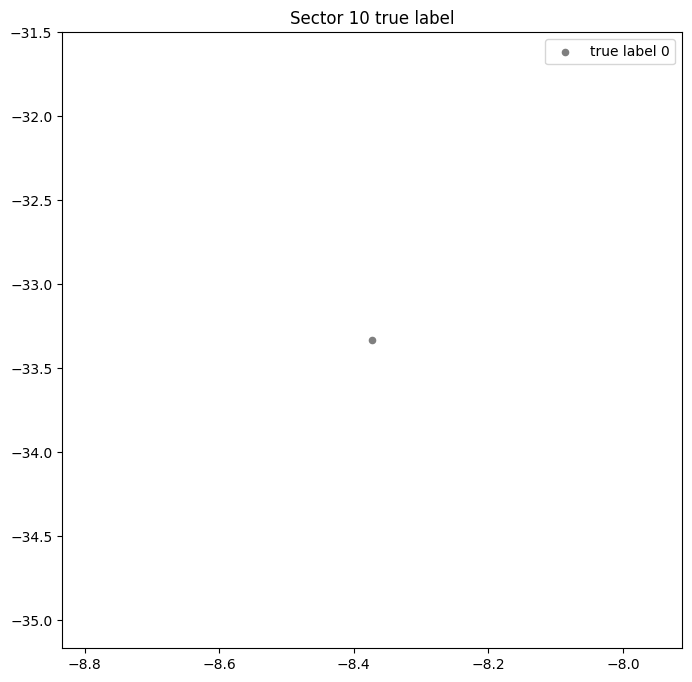

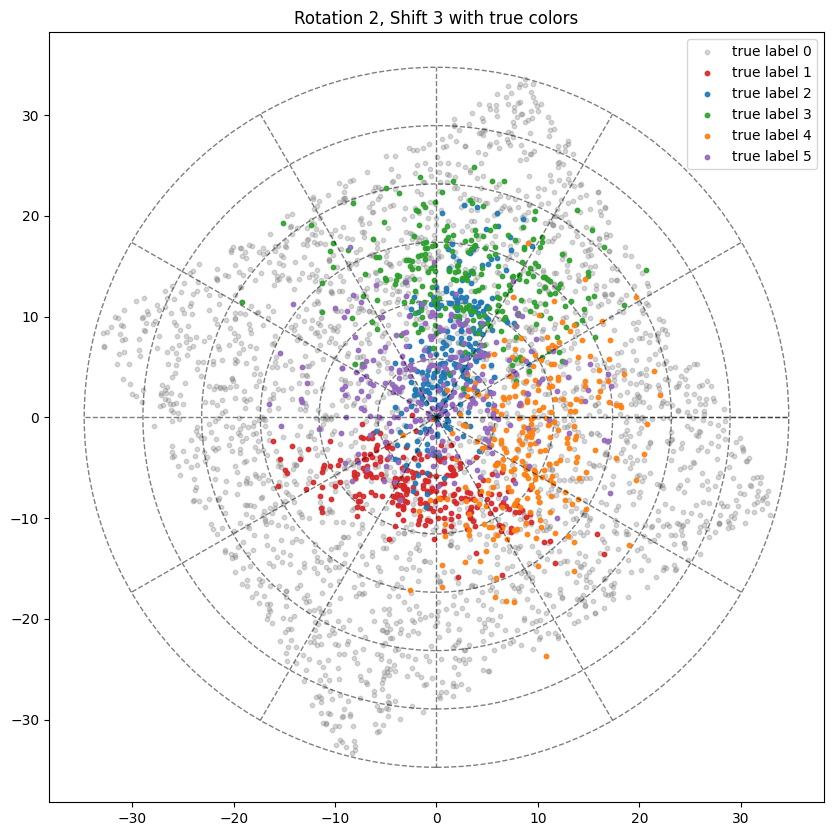

Rotation 3: Angle 240.0 degrees
  Shift 1:
Execution time (softmax): 0 minutes, 1 seconds and 916 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


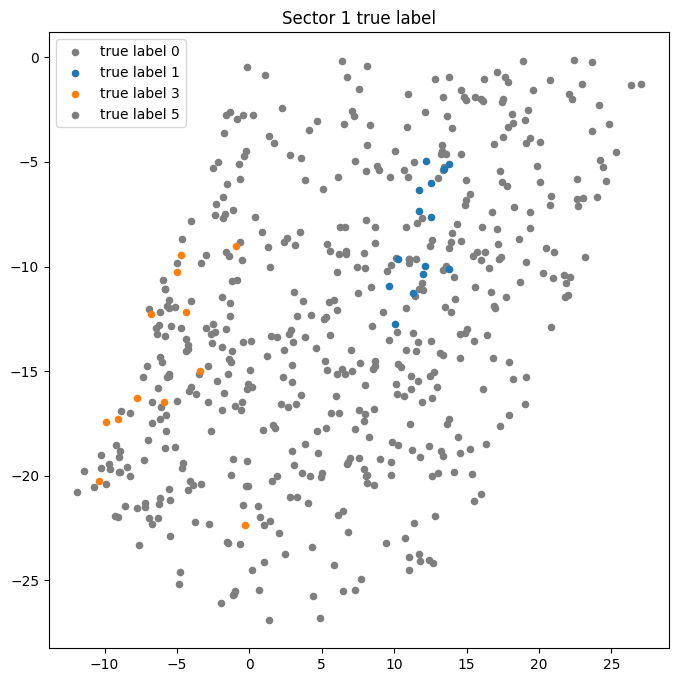

Execution time (softmax): 0 minutes, 6 seconds and 859 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


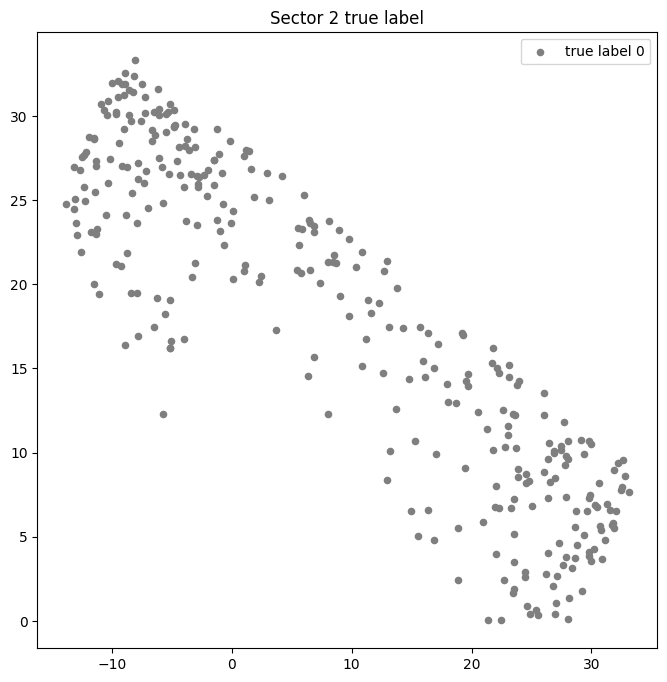

Execution time (softmax): 0 minutes, 1 seconds and 842 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


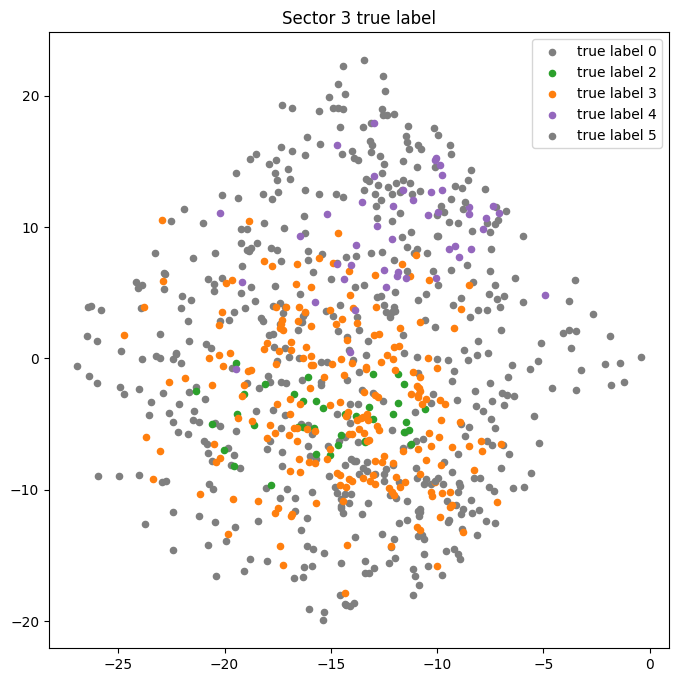

Execution time (softmax): 0 minutes, 1 seconds and 863 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


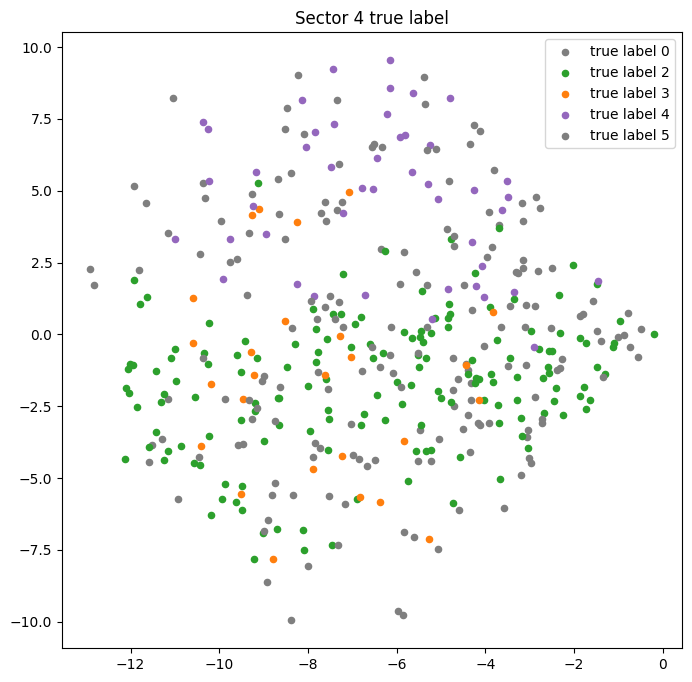

Execution time (softmax): 0 minutes, 0 seconds and 92 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


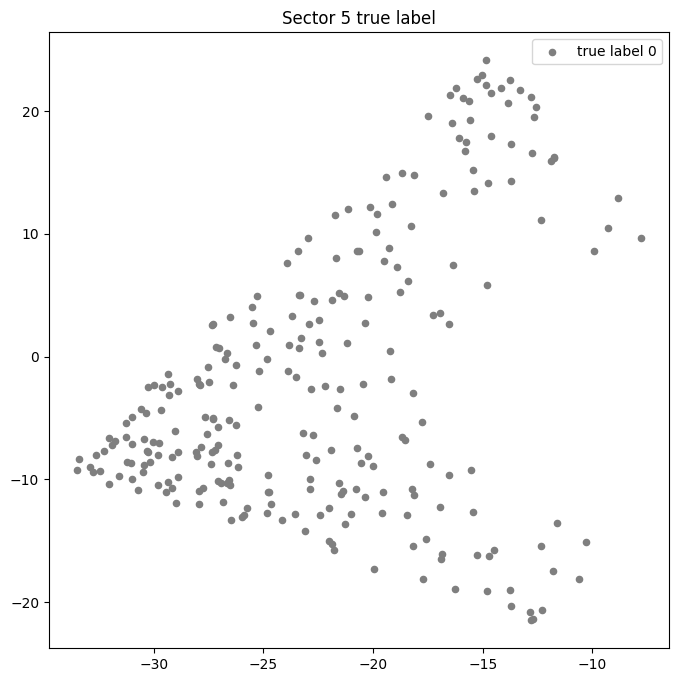

Execution time (softmax): 0 minutes, 1 seconds and 886 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


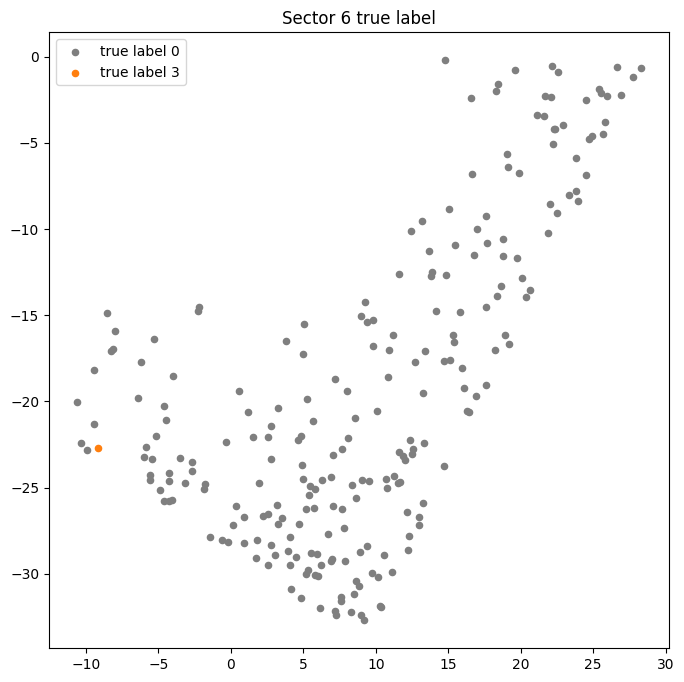

Execution time (softmax): 0 minutes, 3 seconds and 394 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


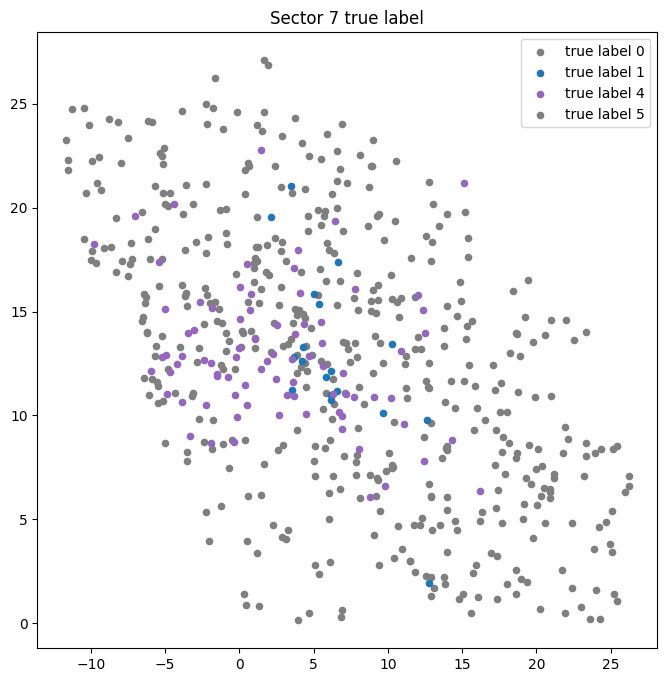

Execution time (softmax): 0 minutes, 1 seconds and 646 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


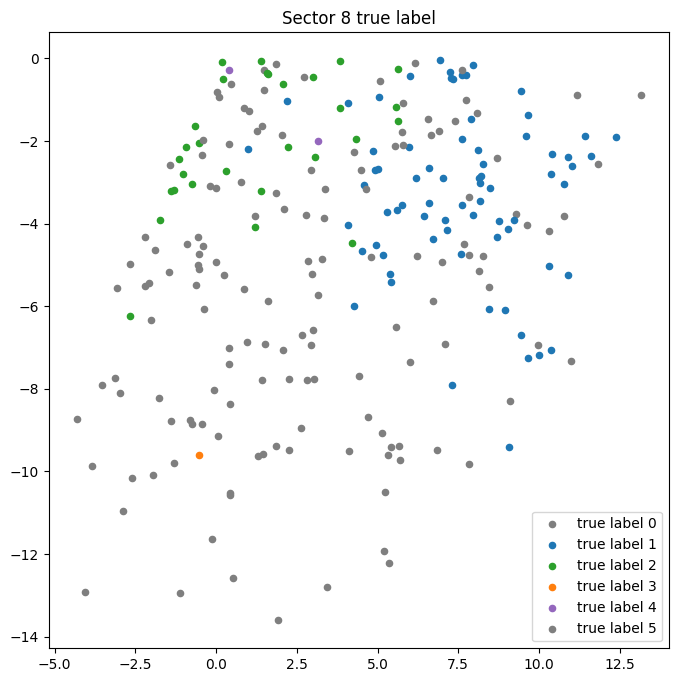

Execution time (softmax): 0 minutes, 4 seconds and 450 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


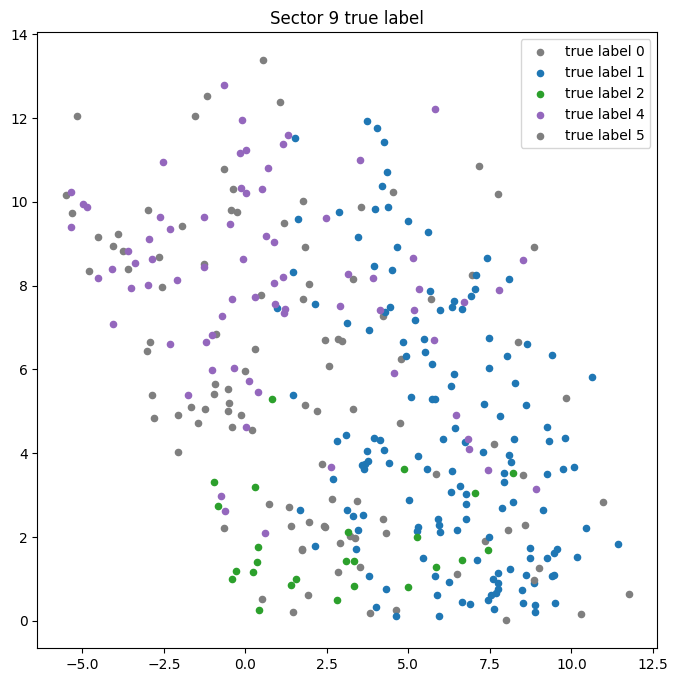

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


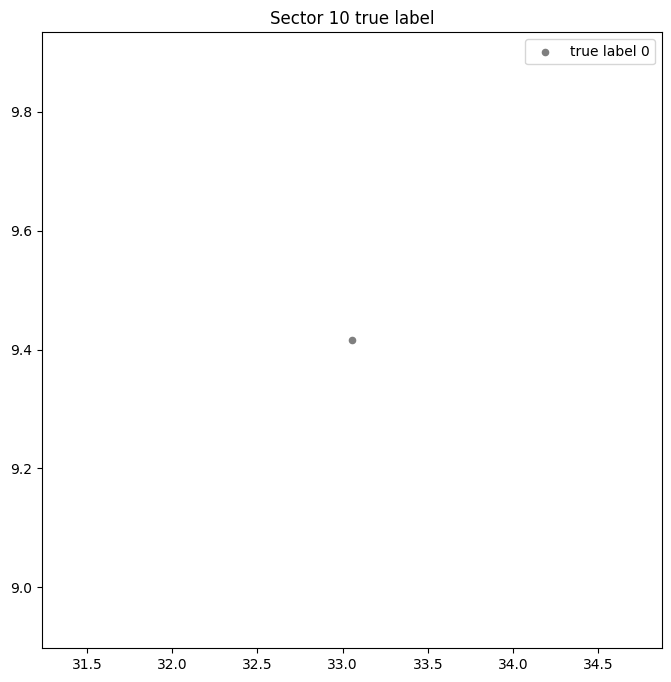

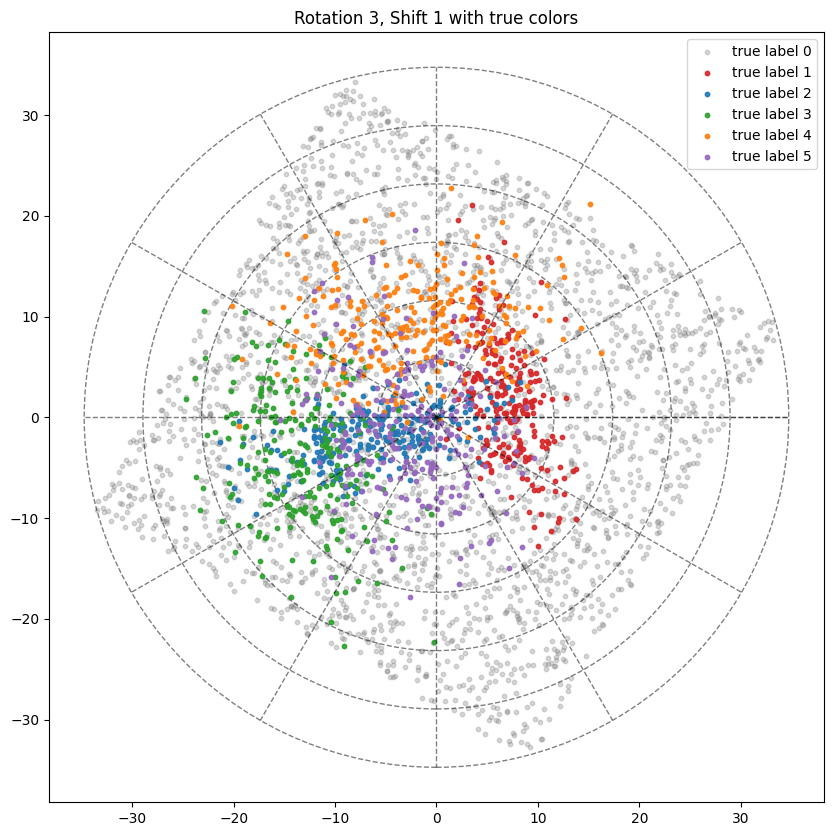

  Shift 2:
Execution time (softmax): 0 minutes, 2 seconds and 77 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


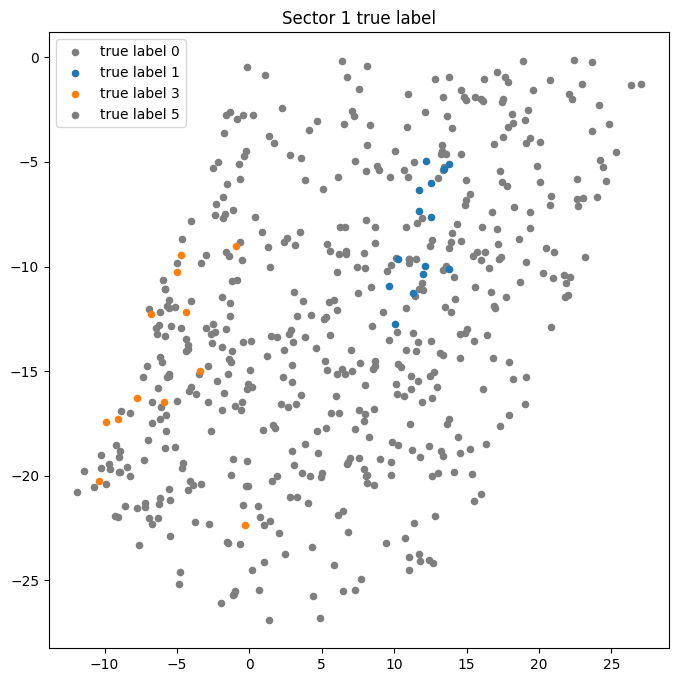

Execution time (softmax): 0 minutes, 7 seconds and 43 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


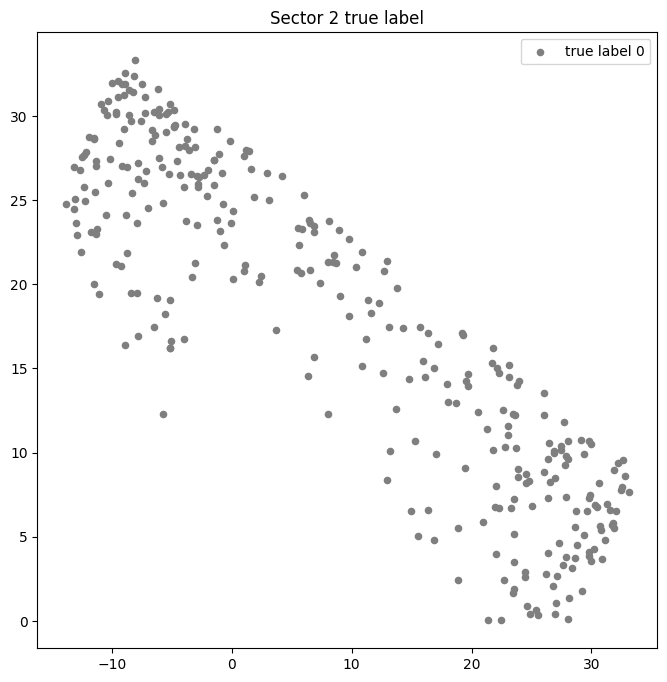

Execution time (softmax): 0 minutes, 1 seconds and 549 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


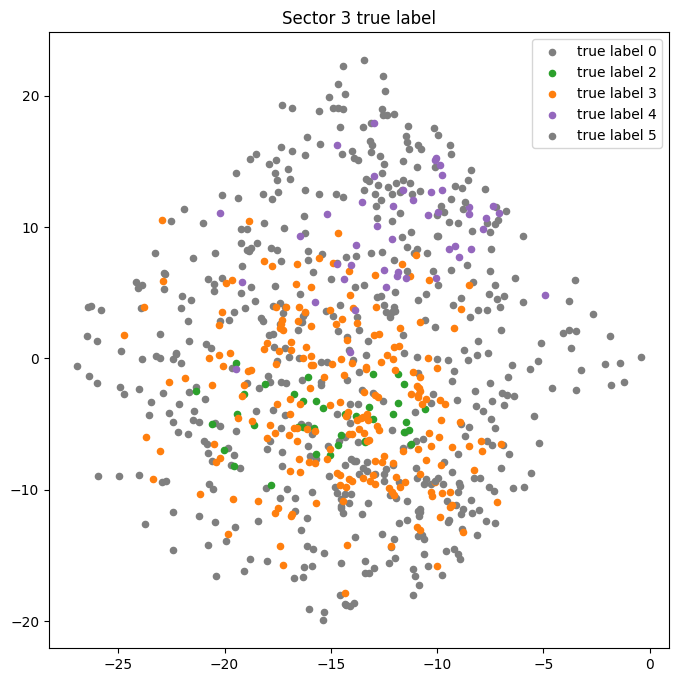

Execution time (softmax): 0 minutes, 4 seconds and 503 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


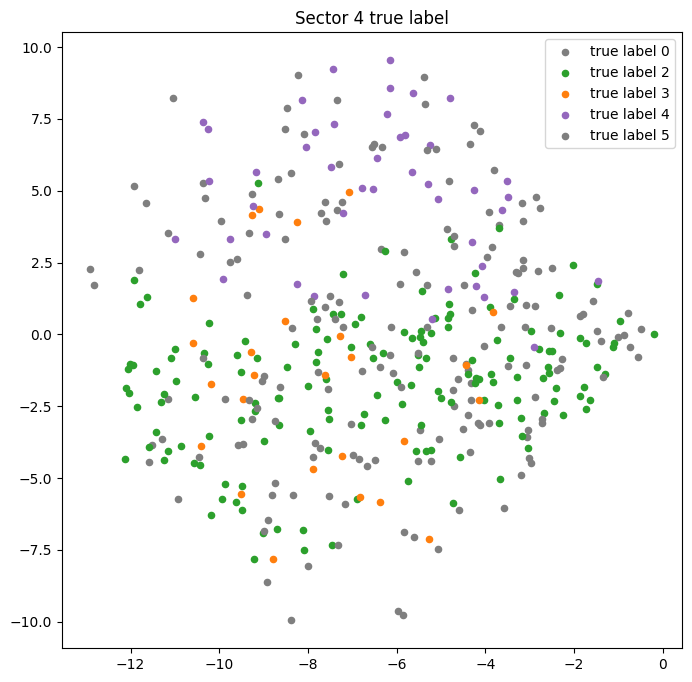

Execution time (softmax): 0 minutes, 3 seconds and 418 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


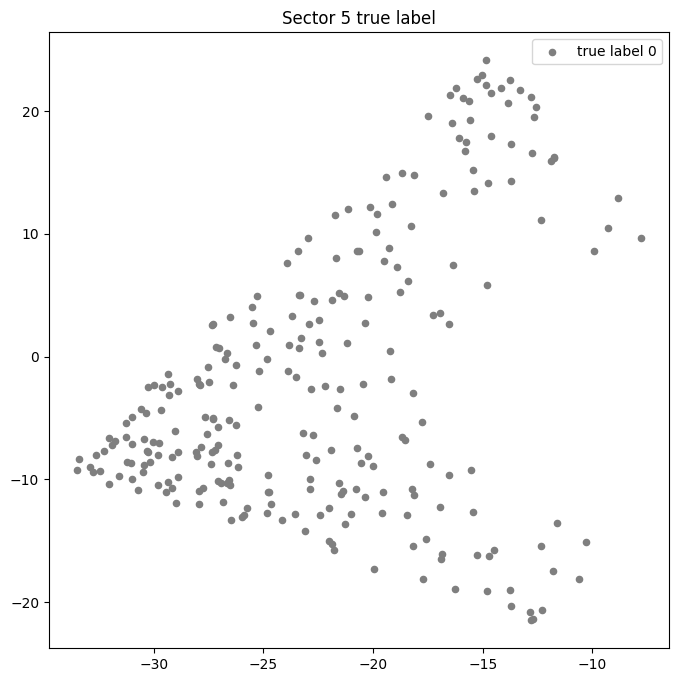

Execution time (softmax): 0 minutes, 5 seconds and 10 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


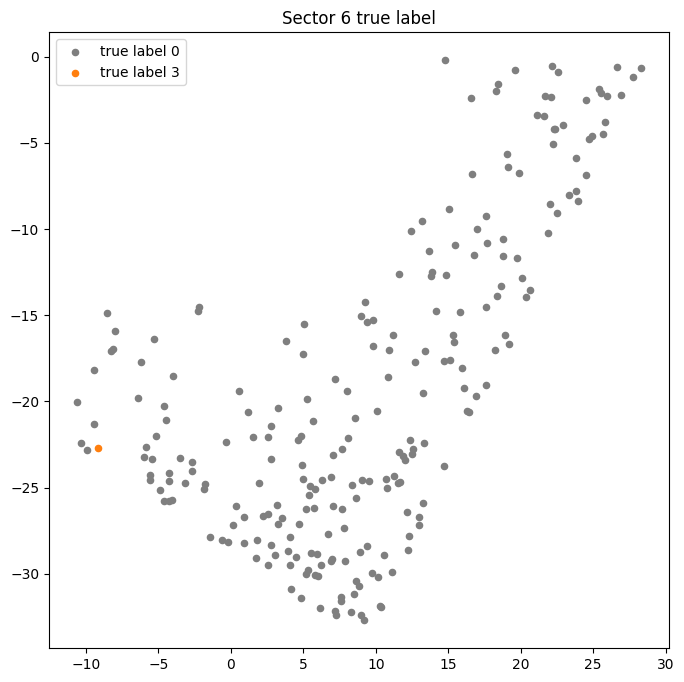

Execution time (softmax): 0 minutes, 3 seconds and 333 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


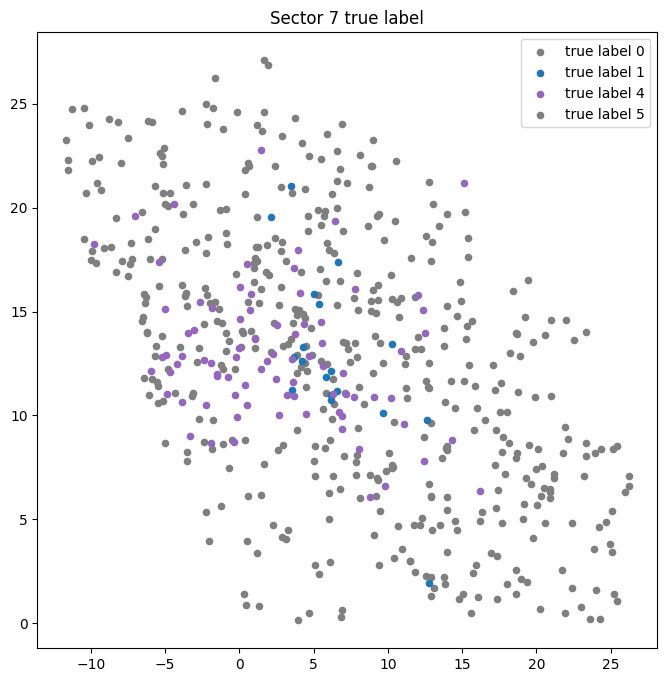

Execution time (softmax): 0 minutes, 2 seconds and 192 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


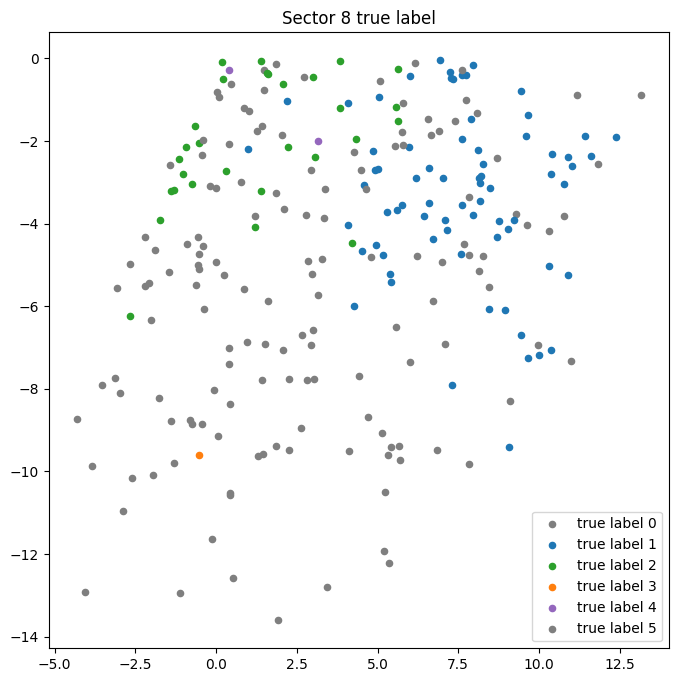

Execution time (softmax): 0 minutes, 1 seconds and 561 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


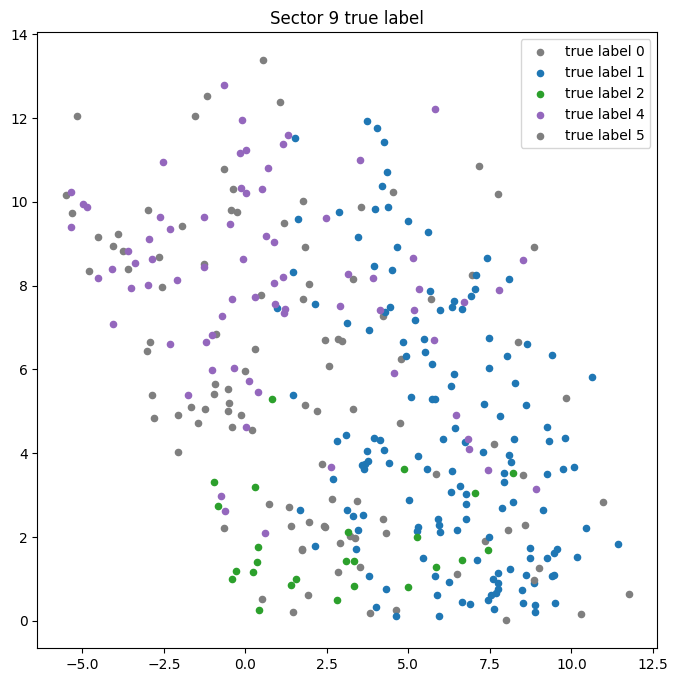

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


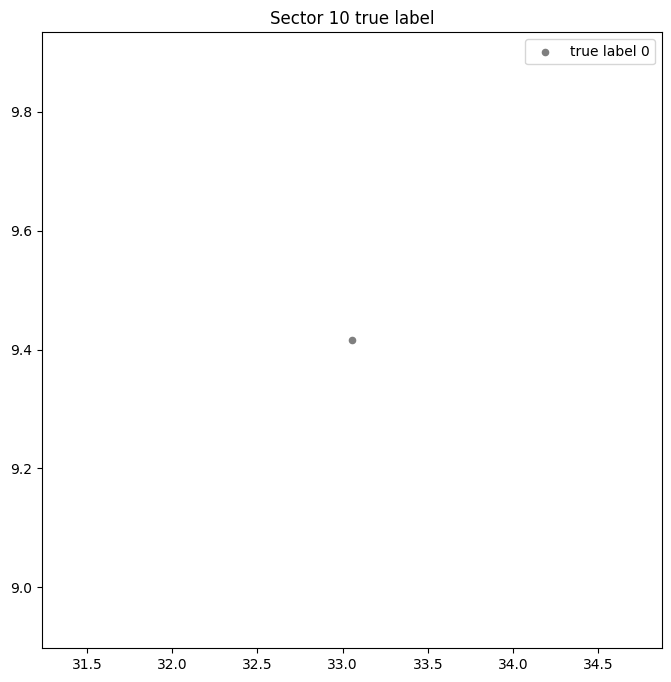

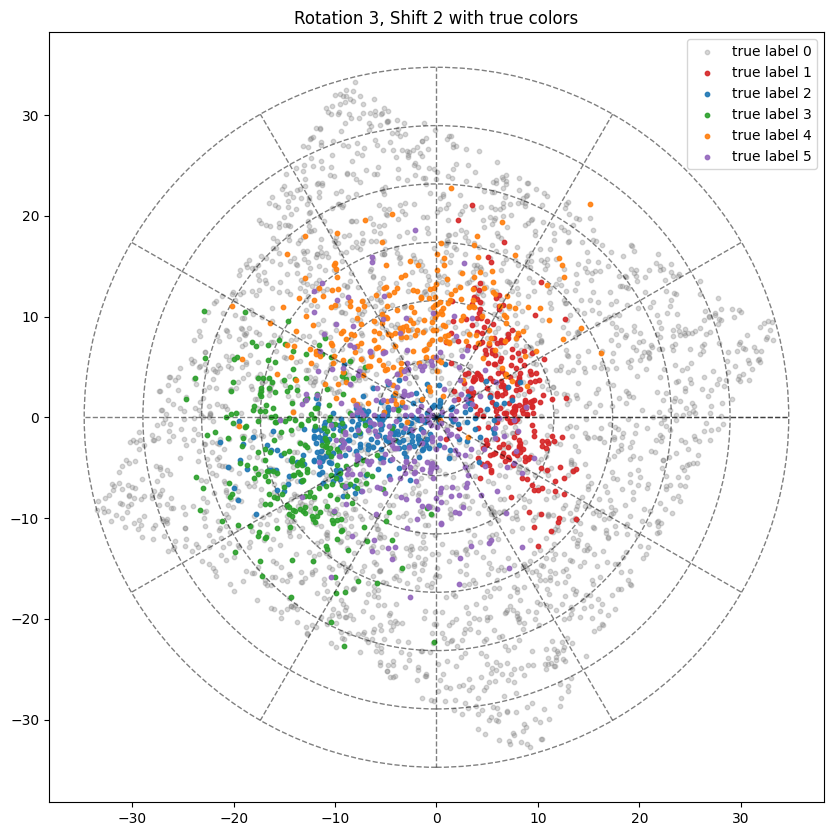

  Shift 3:
Execution time (softmax): 0 minutes, 2 seconds and 191 ms
Number of iterations (softmax): 50
    Sector 1: 5 clusters, Labels: [0, 1, 2, 3, 4], Points: 534
      True label counts in sector 1: {0.0: 498, 1.0: 14, 3.0: 12, 5.0: 10}


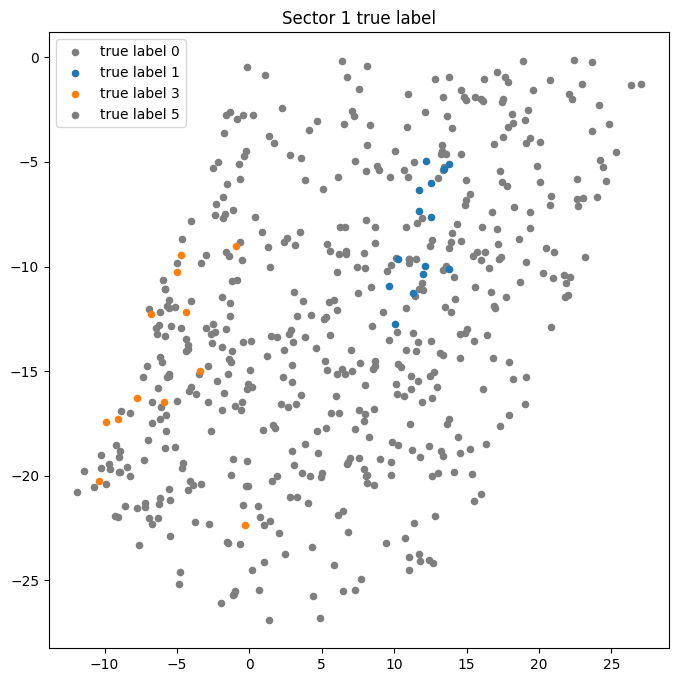

Execution time (softmax): 0 minutes, 7 seconds and 148 ms
Number of iterations (softmax): 184
    Sector 2: 6 clusters, Labels: [5, 6, 7, 8, 9, 10], Points: 321
      True label counts in sector 2: {0.0: 321}


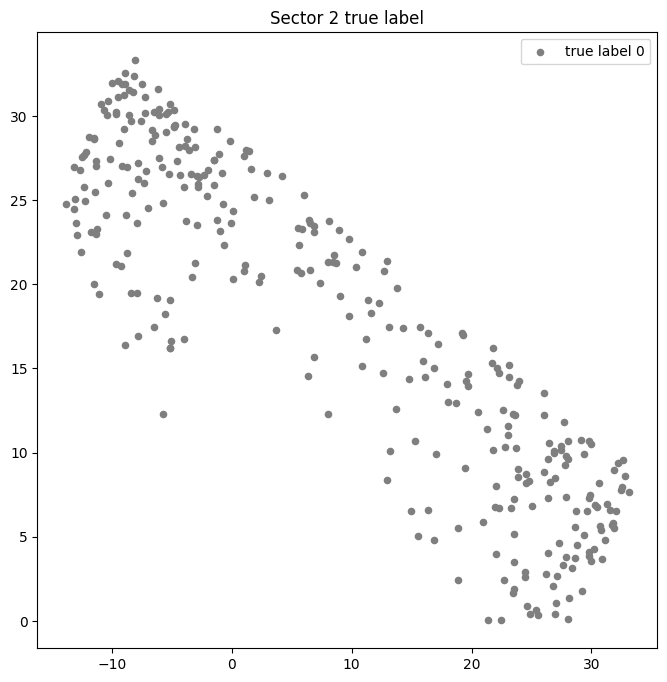

Execution time (softmax): 0 minutes, 1 seconds and 552 ms
Number of iterations (softmax): 42
    Sector 3: 4 clusters, Labels: [11, 12, 13, 14], Points: 821
      True label counts in sector 3: {0.0: 514, 3.0: 210, 4.0: 46, 2.0: 38, 5.0: 13}


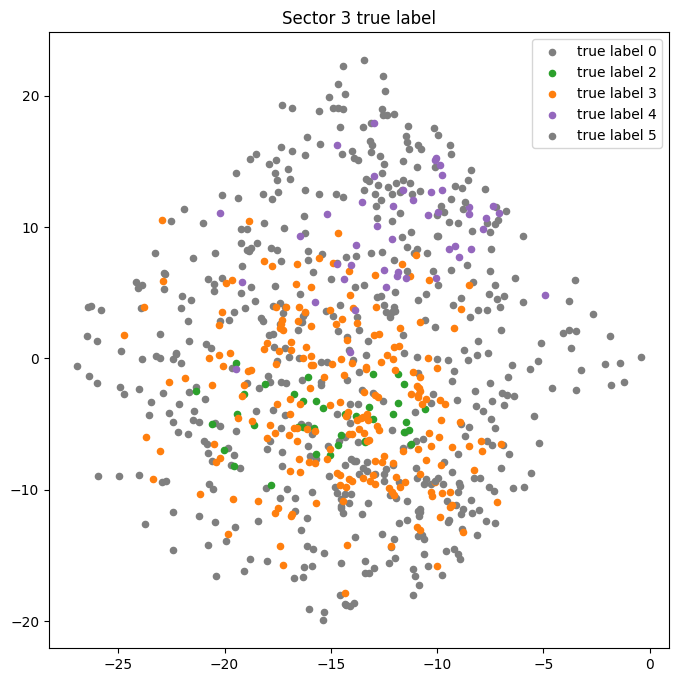

Execution time (softmax): 0 minutes, 3 seconds and 210 ms
Number of iterations (softmax): 108
    Sector 4: 5 clusters, Labels: [15, 16, 17, 18, 19], Points: 409
      True label counts in sector 4: {2.0: 158, 5.0: 111, 0.0: 68, 4.0: 46, 3.0: 26}


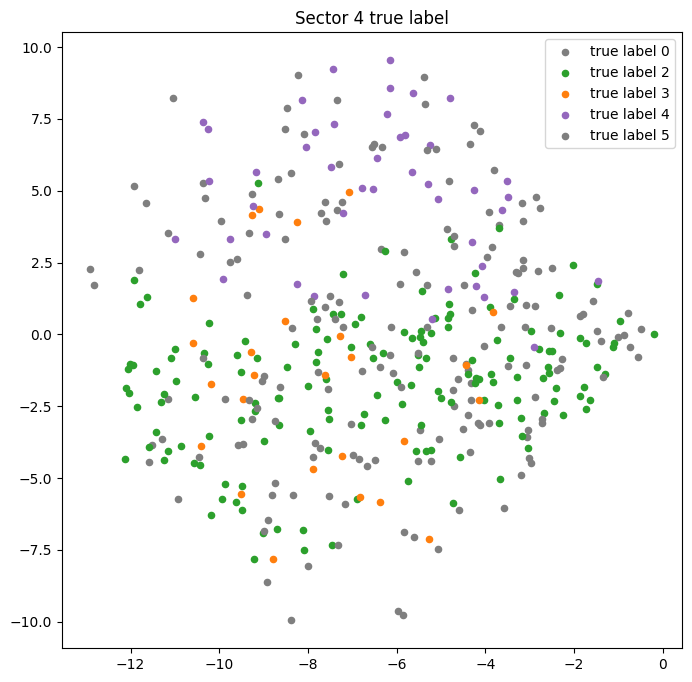

Execution time (softmax): 0 minutes, 3 seconds and 272 ms
Number of iterations (softmax): 83
    Sector 5: 5 clusters, Labels: [20, 21, 22, 23, 24], Points: 258
      True label counts in sector 5: {0.0: 258}


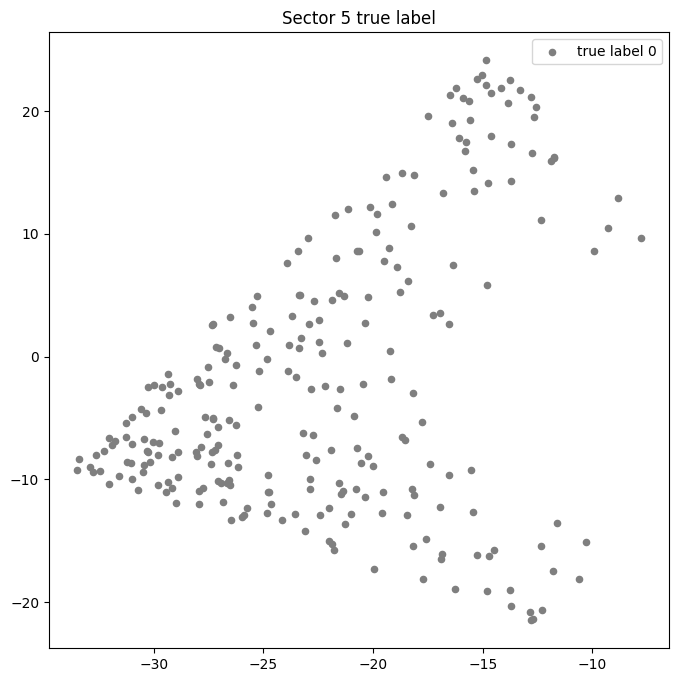

Execution time (softmax): 0 minutes, 4 seconds and 701 ms
Number of iterations (softmax): 135
    Sector 6: 3 clusters, Labels: [25, 26, 27], Points: 235
      True label counts in sector 6: {0.0: 234, 3.0: 1}


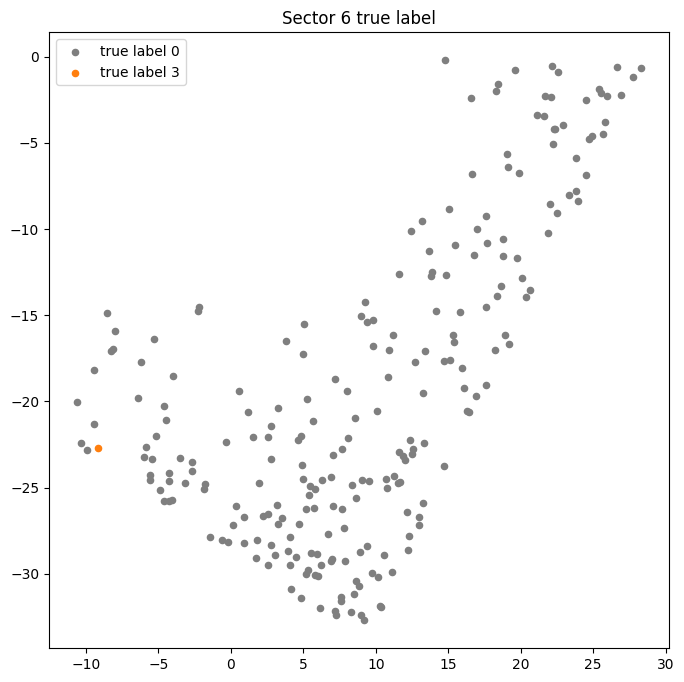

Execution time (softmax): 0 minutes, 3 seconds and 381 ms
Number of iterations (softmax): 87
    Sector 7: 4 clusters, Labels: [28, 29, 30, 31], Points: 572
      True label counts in sector 7: {0.0: 468, 4.0: 82, 1.0: 18, 5.0: 4}


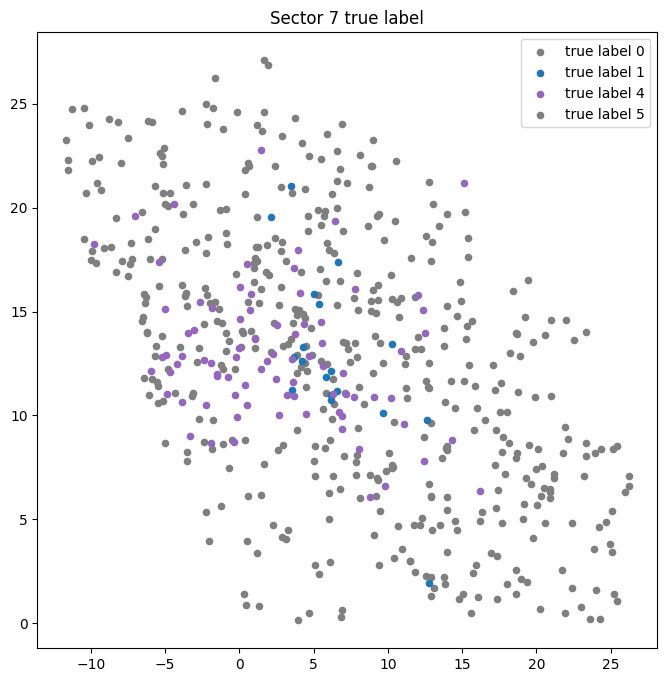

Execution time (softmax): 0 minutes, 1 seconds and 677 ms
Number of iterations (softmax): 54
    Sector 8: 3 clusters, Labels: [32, 33, 34], Points: 249
      True label counts in sector 8: {5.0: 76, 1.0: 72, 0.0: 69, 2.0: 29, 4.0: 2, 3.0: 1}


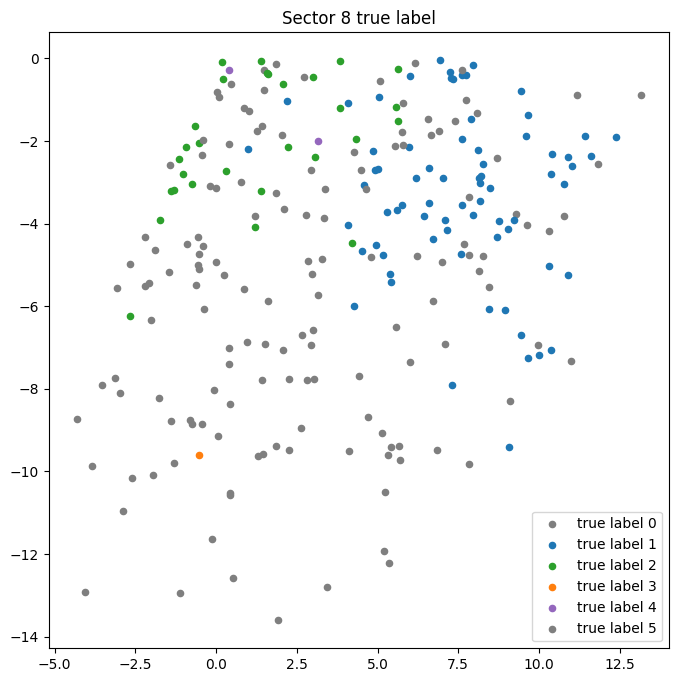

Execution time (softmax): 0 minutes, 2 seconds and 844 ms
Number of iterations (softmax): 111
    Sector 9: 4 clusters, Labels: [35, 36, 37, 38], Points: 350
      True label counts in sector 9: {1.0: 146, 4.0: 74, 0.0: 69, 5.0: 36, 2.0: 25}


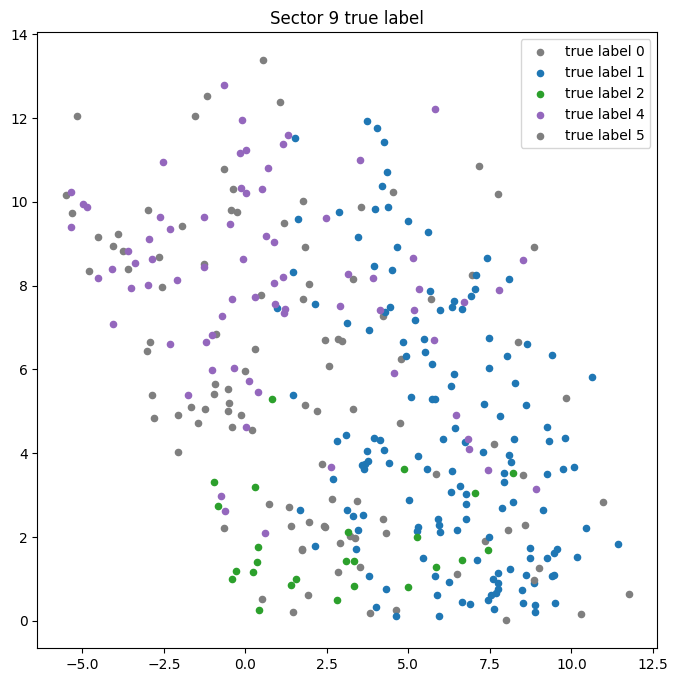

Execution time (softmax): 0 minutes, 0 seconds and 0 ms
Number of iterations (softmax): 2
    Sector 10: 1 clusters, Labels: [39], Points: 1
      True label counts in sector 10: {0.0: 1}


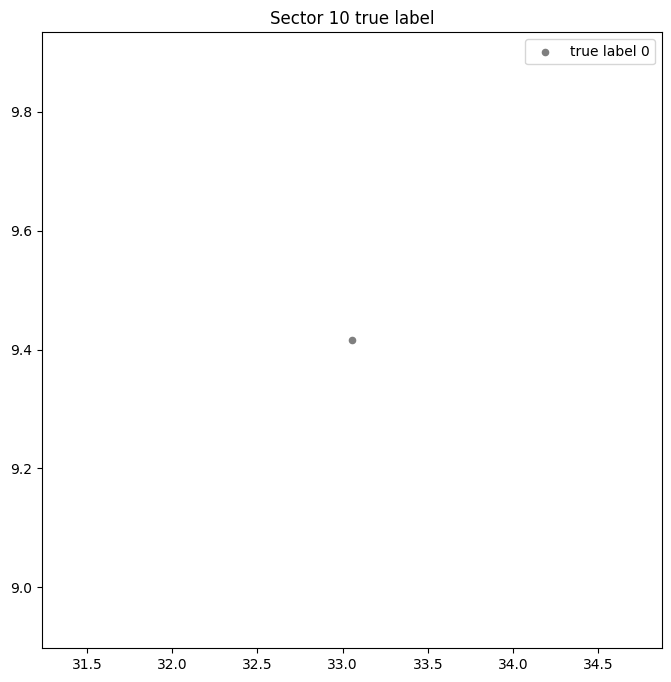

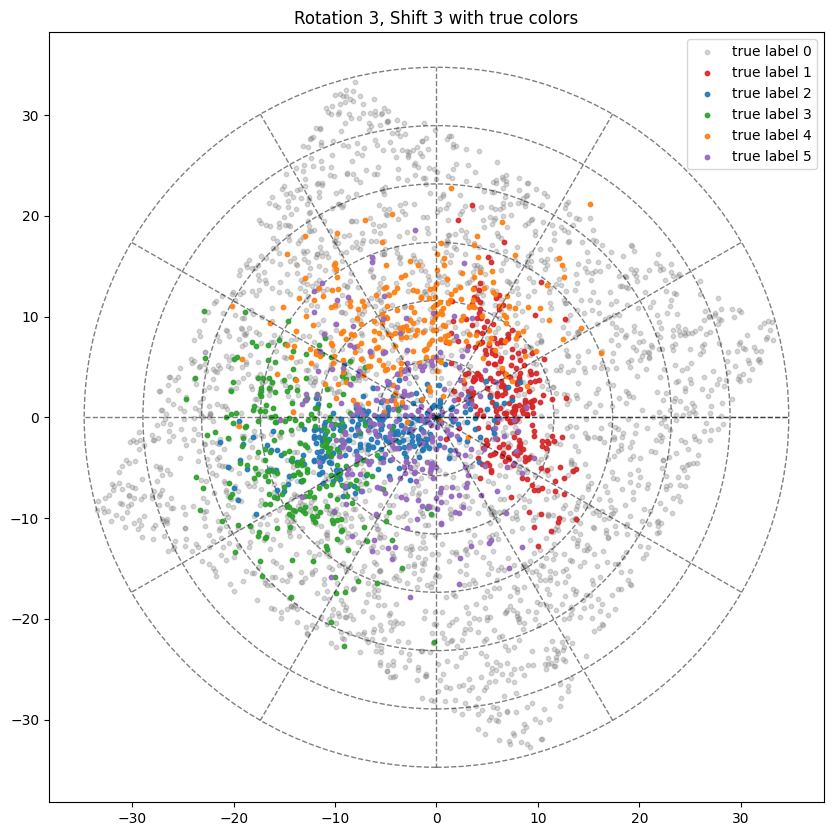

In [7]:
K = 9  
dist_matrix = dist_v_opt

grid_results = run_clustering(df, K, dist_matrix, consensus_clusterings.softmax_clustering_optimized, labels, num_rotations=3, rotation_axis='z', rotation_angle=None, num_shifts=3, num_sectors=3, num_shells=3, projection='xy', colors=colors, alphas=alphas, zorders=zorders)


In [8]:
consensus_labels = consensus_clusterings.consensus_clustering_from_grid(grid_results, solver='cspa', nclass=K, random_state=42, verbose=True)

Cluster Ensembles
    - number of classes: 9
    - solver: cspa
    - length of base clustering labels: 3750
    - number of base clusters: 9


In [9]:
nmi = consensus_clusterings.calculate_nmi(consensus_labels, labels, background_label=0)

NMI (ignoring background points): 0.3889
